# 05. AlphaProg-AGMT: графовая история, цензурированная трудоёмкость и адаптивное объединение

In [1]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)

SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert "Times New Roman" in font_names
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(5))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == ["Times New Roman"]
    fig.savefig(ROOT / "figures/generated" / f"{name}.png", dpi=FIGURE_DPI)
    fig.savefig(ROOT / "figures/generated" / f"{name}.pdf", dpi=FIGURE_DPI)


import time
import random
import gc
from dataclasses import replace
from typing import Any
import joblib
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    log_loss,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from lightgbm import LGBMClassifier
import torch
from torch import nn
from torch.nn import functional as F
from scipy.optimize import minimize
from scipy.special import expit

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_num_threads(2)
SEEDS = [17, 42, 2026]
protocol = json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)
verify_frozen_training_source(ROOT)
assert (
    not protocol["locked_test_opened"]
    or (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists()
)
base_decision = json.loads(
    (ROOT / "dataset/protocol/model_base_selection.json").read_text()
)
BASE_NAME = base_decision["base"]
contract = json.loads(
    (ROOT / "dataset/protocol/robo_feature_contract.json").read_text()
)
feature_names = contract["features"]
numeric_names = [
    name for name in feature_names if name not in contract["categorical"]
]
train_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_train.pkl"
).reset_index(drop=True)
validation_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_features_validation.pkl"
).reset_index(drop=True)
assert set(train_data.student).isdisjoint(validation_data.student)
assert contract["feature_revision"] == "event_prefix_v2"
assert (
    train_data.attrs["feature_revision"]
    == validation_data.attrs["feature_revision"]
    == "event_prefix_v2"
)
modern_execution = json.loads(
    (ROOT / "dataset/protocol/modern_execution.json").read_text()
)
assert (
    modern_execution["completed"]
    and modern_execution["feature_revision"] == contract["feature_revision"]
)
episode_data = pd.read_pickle(
    ROOT / "dataset/processed/robo_episode_features.pkl"
)
graph_archive = json.loads(
    (ROOT / "dataset/processed/program_graphs.json").read_text()
)
problem_metadata = pd.read_pickle(
    ROOT / "dataset/processed/robo_problem_features.pkl"
)
problem_to_index = {
    int(problem): index + 1
    for index, problem in enumerate(sorted(problem_metadata.index))
}
N_TASKS = len(problem_to_index)
GRAPH_MODEL_DIR = ROOT / "artifacts/runtime/proposed"
GRAPH_MODEL_DIR.mkdir(exist_ok=True)
graph_curves, graph_efficiency = [], []
component_results, hazard_results, gate_results = {}, {}, {}


## Покрытие структурного представления

Какая доля кода может быть представлена структурно, а какая требует резервной цепочки символов? Таблица описывает фактически доступные префиксы в последовательностях входов. Повторное использование одного прошлого состояния в нескольких запросах учитывается как несколько позиций контекста; число уникальных программ показано отдельно. Ограничение 64 узла фиксируется до оценивания качества.

In [2]:
coverage = []
for split, frame in [("Train", train_data), ("Validation", validation_data)]:
    source = pd.read_pickle(
        ROOT / f"dataset/processed/robo_sequences_{split.lower()}.pkl"
    )
    columns = {name: index for index, name in enumerate(source["columns"])}
    observed_rows = np.asarray(
        [row for history in source["sequences"] for row in history],
        dtype=float,
    )
    used_ids = observed_rows[:, columns["graph_id"]].astype(int)
    counts = np.asarray(
        [len(graph_archive["graphs"][index]["labels"]) for index in used_ids]
    )
    coverage.append(
        {
            "Split": split,
            "n": len(observed_rows),
            "Programs": len(np.unique(used_ids)),
            "Invalid fraction": observed_rows[
                :, columns["code_invalid"]
            ].mean(),
            "Over 64 nodes": (counts > 64).mean(),
            "Median nodes": np.median(counts),
        }
    )
table(
    pd.DataFrame(coverage),
    "Таблица 1. Покрытие программных структур",
    "05_graph_coverage",
)


Таблица 1. Покрытие программных структур

,Split,n,Programs,Invalid fraction,Over 64 nodes,Median nodes
0,Train,1137570,4960,0.00142,0.0,5.0
1,Validation,237999,1640,0.00102,0.0,5.0


## Архитектура и пути обучения

Схема показывает поток доступных входов и прогнозов. Обучение использует целевые метки только в функциях потерь. Веса fusion оцениваются только после получения OOF-прогнозов компонентов. Текущая программа, итоговое число её запусков и её успешность никогда не являются входными признаками.

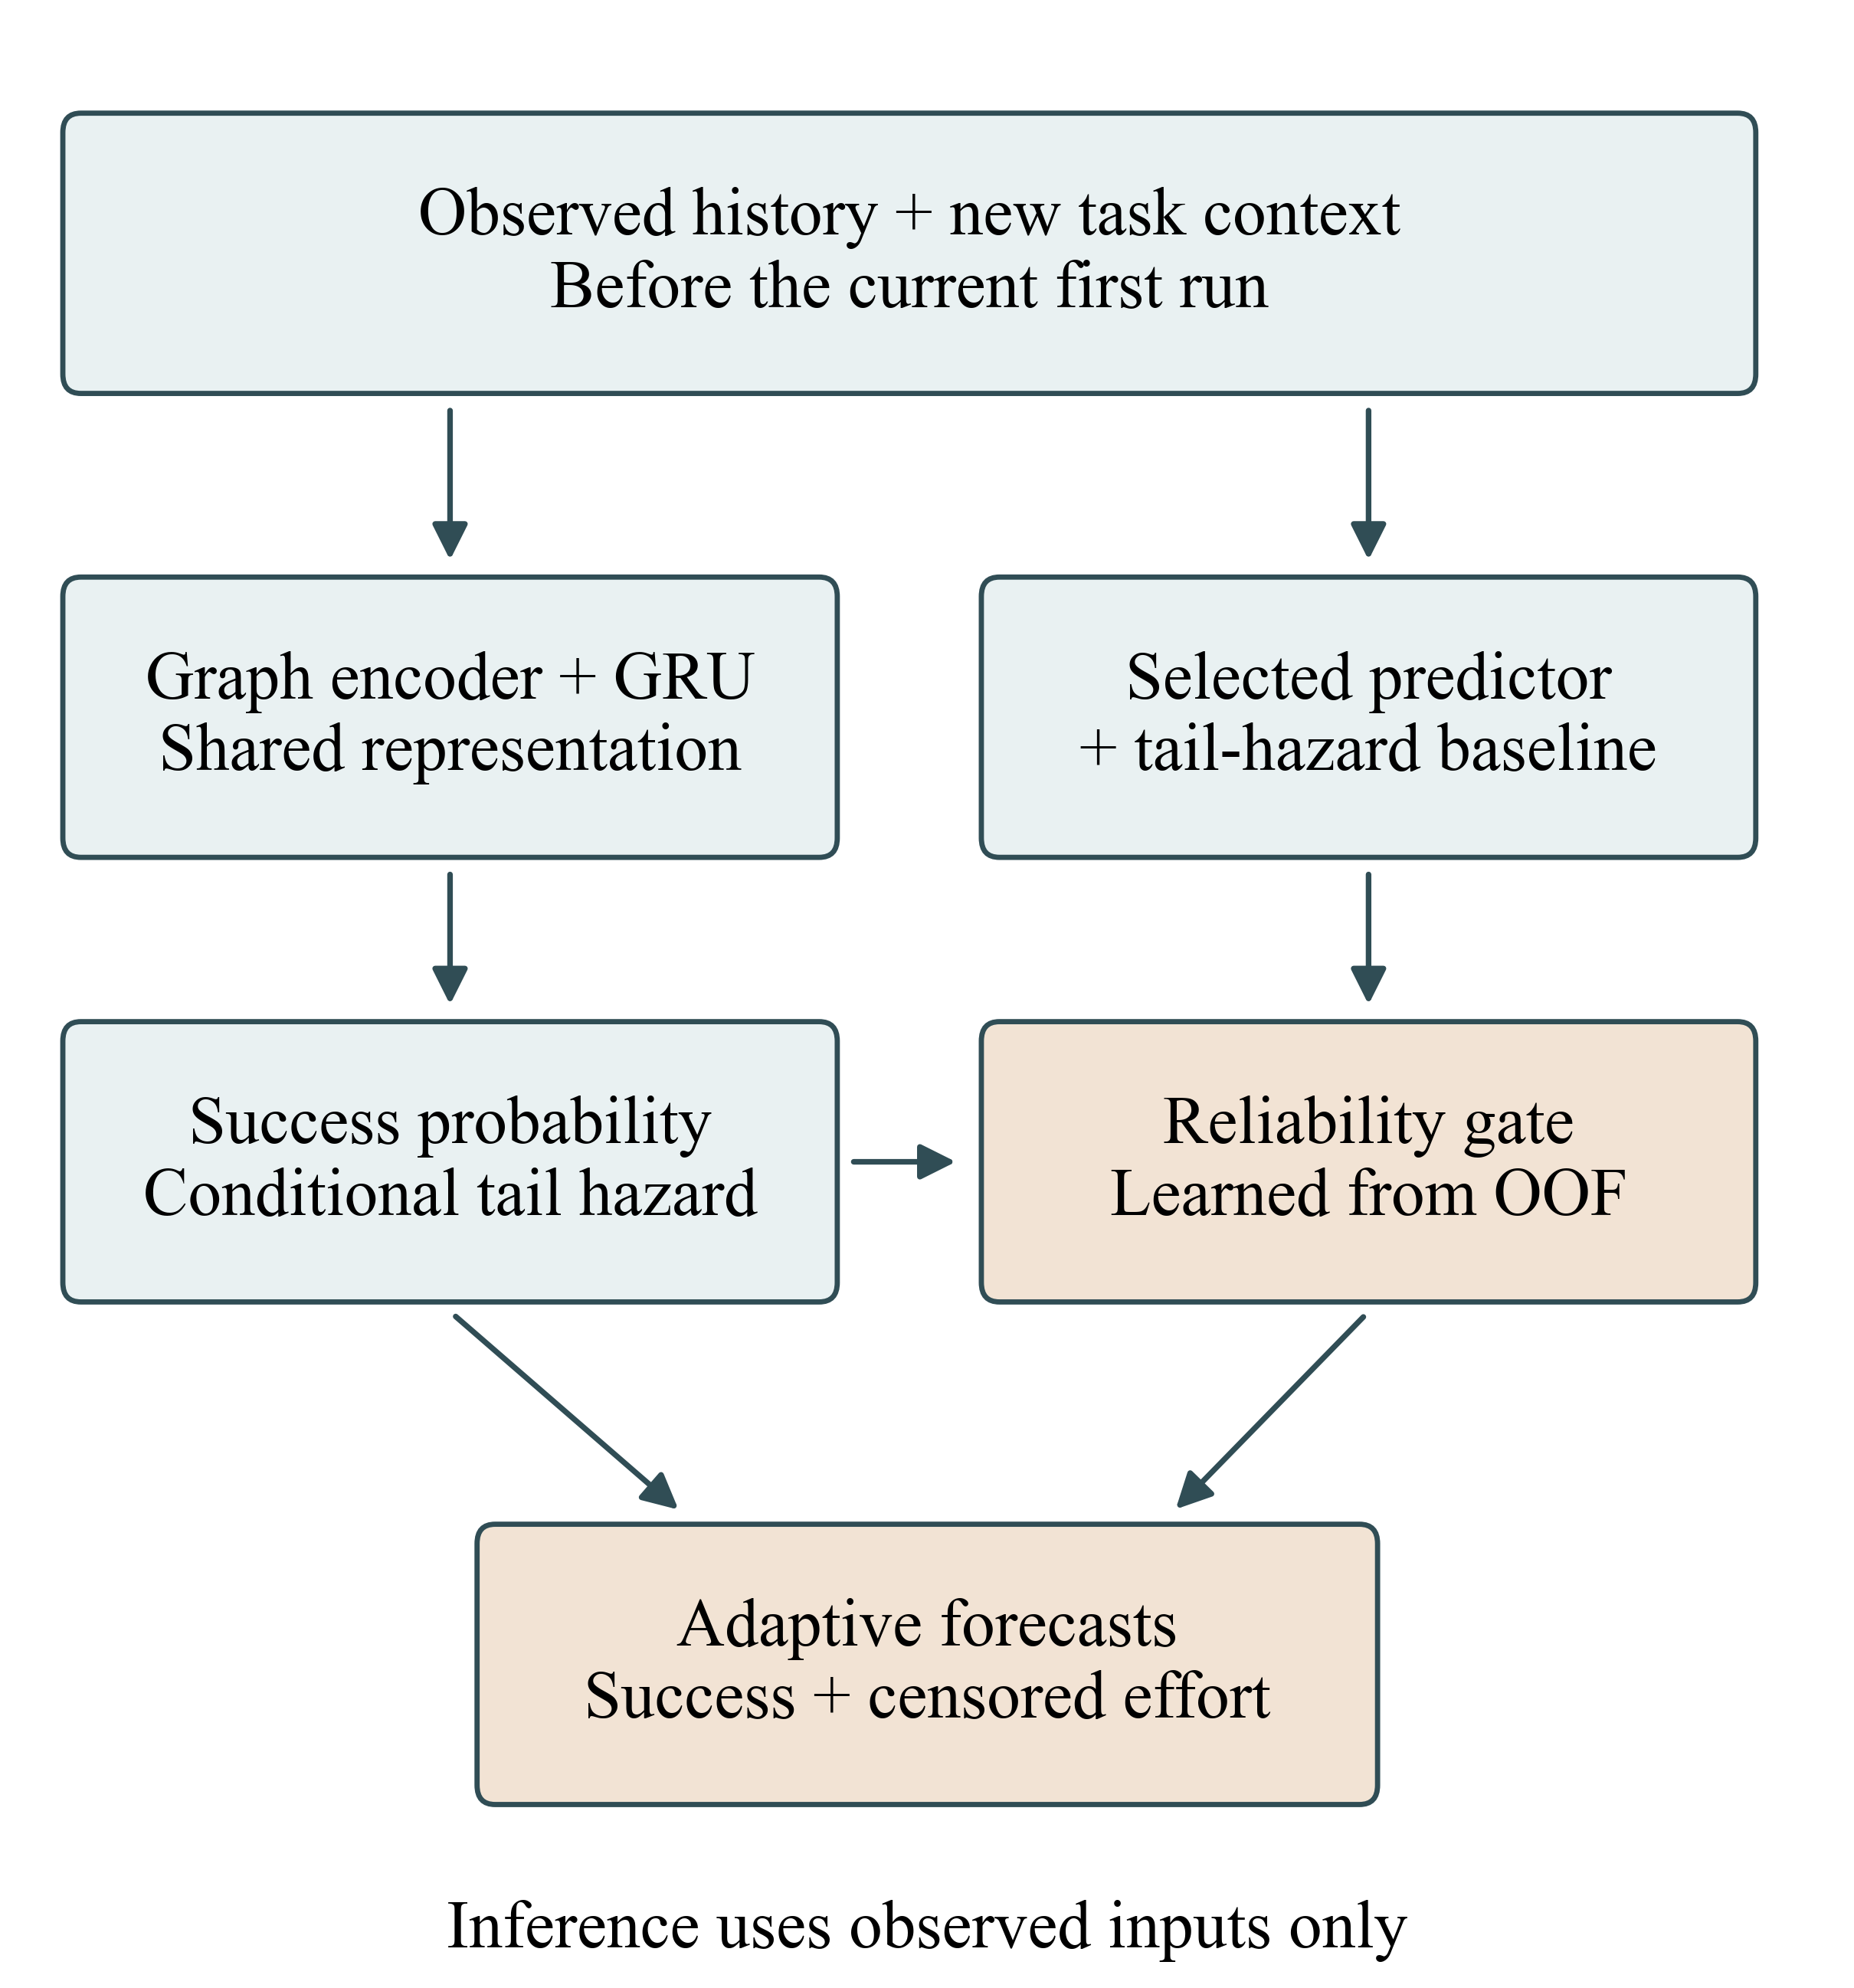

In [3]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(6.8, 7.3), layout="constrained")
ax.set(xlim=(0, 10), ylim=(0, 10))
ax.axis("off")
boxes = {
    "inputs": (
        0.3,
        8.2,
        9.2,
        1.25,
        "Observed history + new task context\nBefore the current first run",
    ),
    "graph": (
        0.3,
        5.8,
        4.1,
        1.25,
        "Graph encoder + GRU\nShared representation",
    ),
    "base": (
        5.4,
        5.8,
        4.1,
        1.25,
        "Selected predictor\n+ tail-hazard baseline",
    ),
    "expert": (
        0.3,
        3.5,
        4.1,
        1.25,
        "Success probability\nConditional tail hazard",
    ),
    "gate": (5.4, 3.5, 4.1, 1.25, "Reliability gate\nLearned from OOF"),
    "result": (
        2.6,
        0.9,
        4.8,
        1.25,
        "Adaptive forecasts\nSuccess + censored effort",
    ),
}
for key, (x, y, width, height, label) in boxes.items():
    color = "#E9F1F2" if key not in ["gate", "result"] else "#F2E3D4"
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.10",
            facecolor=color,
            edgecolor="#304D55",
            linewidth=1.4,
        )
    )
    ax.text(
        x + width / 2,
        y + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=18,
    )
for start, end in [
    ((2.35, 8.05), (2.35, 7.2)),
    ((7.45, 8.05), (7.45, 7.2)),
    ((2.35, 5.65), (2.35, 4.9)),
    ((7.45, 5.65), (7.45, 4.9)),
    ((4.55, 4.125), (5.2, 4.125)),
    ((7.45, 3.35), (6.35, 2.3)),
    ((2.35, 3.35), (3.65, 2.3)),
]:
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=20,
            color="#304D55",
            linewidth=1.5,
        )
    )
ax.text(
    5,
    0.15,
    "Inference uses observed inputs only",
    ha="center",
    va="center",
    fontsize=18,
)
save_figure(fig, "05_architecture")
plt.show()


## Компоненты и функции потерь

In [4]:
from dataclasses import dataclass


@dataclass(frozen=True)
class GraphConfig:
    """Explicit capacity and ablation controls for the trajectory expert."""

    width: int = 32
    graph_steps: int = 2
    use_code: bool = True
    use_edges: bool = True
    use_recurrence: bool = True
    auxiliary_weight: float = 0.1
    weight_decay: float = 1e-4
    dropout: float = 0.1
    max_nodes: int = 64


class ProgramGraphEncoder(nn.Module):
    """Encode command content, nesting and ordered sibling relations."""

    def __init__(
        self,
        vocabulary_size: int,
        width: int,
        steps: int,
        use_edges: bool,
        graph_tensors: dict[str, torch.Tensor],
    ):
        super().__init__()
        self.use_edges = use_edges
        self.embedding = nn.Embedding(vocabulary_size, width, padding_idx=0)
        self.self_maps = nn.ModuleList(
            nn.Linear(width, width) for _ in range(steps)
        )
        self.parent_maps = nn.ModuleList(
            nn.Linear(width, width, bias=False) for _ in range(steps)
        )
        self.previous_maps = nn.ModuleList(
            nn.Linear(width, width, bias=False) for _ in range(steps)
        )
        self.norms = nn.ModuleList(nn.LayerNorm(width) for _ in range(steps))
        for name, values in graph_tensors.items():
            # Syntax is input data, not learned state or a program-ID embedding.
            self.register_buffer(name, values, persistent=False)

    def forward(self, graph_ids: torch.Tensor) -> torch.Tensor:
        unique_ids, inverse = torch.unique(graph_ids, return_inverse=True)
        token = self.token[unique_ids]
        mask = self.node_mask[unique_ids].unsqueeze(-1)
        hidden = self.embedding(token) * mask
        parent = self.parent[unique_ids]
        previous = self.previous[unique_ids]
        for own_map, parent_map, previous_map, norm in zip(
            self.self_maps, self.parent_maps, self.previous_maps, self.norms
        ):
            messages = own_map(hidden)
            if self.use_edges:
                parent_hidden = hidden.gather(
                    1, parent.clamp(min=0).unsqueeze(-1).expand_as(hidden)
                )
                previous_hidden = hidden.gather(
                    1, previous.clamp(min=0).unsqueeze(-1).expand_as(hidden)
                )
                messages = messages + parent_map(parent_hidden) * (
                    parent >= 0
                ).unsqueeze(-1)
                messages = messages + previous_map(previous_hidden) * (
                    previous >= 0
                ).unsqueeze(-1)
            else:
                # Keep every parameter active in the topology-free capacity control.
                messages = messages + parent_map(hidden) + previous_map(hidden)
            hidden = norm(hidden + F.gelu(messages)) * mask
        pooled = hidden.sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return pooled[inverse].reshape(*graph_ids.shape, pooled.shape[-1])


class TrajectoryExpert(nn.Module):
    """Share a causal graph and process-history representation across two tasks."""

    def __init__(
        self,
        vocabulary_size: int,
        graph_tensors: dict[str, torch.Tensor],
        n_process: int,
        n_context: int,
        config: GraphConfig,
    ):
        super().__init__()
        self.config = config
        self.code = (
            ProgramGraphEncoder(
                vocabulary_size,
                config.width,
                config.graph_steps,
                config.use_edges,
                graph_tensors,
            )
            if config.use_code
            else None
        )
        self.event_projection = nn.Sequential(
            nn.Linear(
                (config.width if config.use_code else 0) + n_process,
                config.width,
            ),
            nn.GELU(),
            nn.Dropout(config.dropout),
        )
        self.recurrent = (
            nn.GRU(config.width, config.width, batch_first=True)
            if config.use_recurrence
            else None
        )
        self.context = nn.Sequential(
            nn.Linear(n_context, config.width), nn.GELU()
        )
        self.shared = nn.Sequential(
            nn.Linear(2 * config.width, config.width),
            nn.GELU(),
            nn.Dropout(config.dropout),
        )
        self.success = nn.Linear(config.width, 1)
        self.tail_hazard = nn.Linear(config.width, 1)
        if config.auxiliary_weight == 0:
            self.tail_hazard.requires_grad_(False)

    def forward(
        self, batch: dict[str, torch.Tensor]
    ) -> tuple[torch.Tensor, torch.Tensor]:
        content = (
            torch.cat([self.code(batch["graph_id"]), batch["process"]], dim=-1)
            if self.code is not None
            else batch["process"]
        )
        episodes = self.event_projection(content)
        length = batch["length"]
        if self.config.use_recurrence:
            states, _ = self.recurrent(episodes)
            rows = torch.arange(len(length), device=states.device)
            history = states[rows, (length - 1).clamp(min=0)]
        else:
            steps = torch.arange(
                episodes.shape[1], device=episodes.device
            ).unsqueeze(0)
            valid = (steps < length.unsqueeze(1)).unsqueeze(-1)
            history = (episodes * valid).sum(dim=1) / length.clamp(
                min=1
            ).unsqueeze(1)
        history = history * (length > 0).unsqueeze(1)
        hidden = self.shared(
            torch.cat([history, self.context(batch["context"])], dim=1)
        )
        return self.success(hidden).squeeze(-1), self.tail_hazard(
            hidden
        ).squeeze(-1)


def trajectory_loss(
    success_logit: torch.Tensor,
    hazard_logit: torch.Tensor,
    batch: dict[str, torch.Tensor],
    auxiliary_weight: float,
) -> torch.Tensor:
    """Combine first-run BCE with a right-censored geometric tail likelihood."""
    primary = F.binary_cross_entropy_with_logits(success_logit, batch["y"])
    failed_first = 1 - batch["y"]
    remaining_runs = (batch["effort_runs"] - 1).clamp(min=0)
    event = batch["effort_observed"] * failed_first
    failures = remaining_runs * failed_first - event
    assert bool((failures >= 0).all().item())
    likelihood = event * F.softplus(-hazard_logit) + failures * F.softplus(
        hazard_logit
    )
    # Exposure normalization keeps long censored records from setting loss scale.
    exposure = (event + failures).sum().clamp(min=1)
    return primary + auxiliary_weight * likelihood.sum() / exposure


In [6]:
GRAPH_HISTORY = 32

OBSERVED_PROCESS_COLUMNS = [
    "solved",
    "first_correct",
    "first_observed",
    "log_time",
    "log_n_edits",
    "log_n_executions",
    "local_code_mean",
    "local_code_std",
    "code_f",
    "code_l",
    "code_r",
    "code_s",
    "code_R",
    "code_W",
    "code_I",
    "code_ELSE",
    "code_UNKNOWN",
    "code_nodes",
    "code_depth",
    "code_length",
    "code_depth_sum",
    "code_invalid",
]


HISTORY_TASK_FEATURES = {
    "task_level": "q_level",
    "task_diamonds": "q_diamonds",
    "task_repeat": "q_repeat",
    "task_while": "q_while",
    "task_if": "q_if",
    "task_if_else": "q_if-else",
    "task_position": "q_position",
    "task_shoot": "q_shoot",
}

PROCESS_COLUMNS = OBSERVED_PROCESS_COLUMNS + list(HISTORY_TASK_FEATURES)


def graph_history_arrays(
    frame: pd.DataFrame,
    sequence_source: dict,
    task_metadata: pd.DataFrame,
) -> dict[str, np.ndarray]:
    """Encode observed past prefixes together with their known task descriptions."""

    assert sequence_source["feature_revision"] == "event_prefix_v2"

    assert np.array_equal(
        frame.id.to_numpy(),
        np.asarray(sequence_source["ids"]),
    )

    column_index = {
        name: index for index, name in enumerate(sequence_source["columns"])
    }

    assert task_metadata.index.is_unique

    metadata_values = task_metadata.loc[
        :,
        list(HISTORY_TASK_FEATURES.values()),
    ].to_numpy(dtype=np.float32)

    assert np.isfinite(metadata_values).all()

    task_lookup = {
        int(task): values
        for task, values in zip(
            task_metadata.index,
            metadata_values,
        )
    }

    observed_indices = [
        column_index[name] for name in OBSERVED_PROCESS_COLUMNS
    ]

    n_observed = len(OBSERVED_PROCESS_COLUMNS)

    graph_ids = np.zeros(
        (len(frame), GRAPH_HISTORY),
        dtype=np.int64,
    )

    process = np.full(
        (
            len(frame),
            GRAPH_HISTORY,
            len(PROCESS_COLUMNS),
        ),
        np.nan,
        dtype=np.float32,
    )

    length = np.zeros(
        len(frame),
        dtype=np.int64,
    )

    for row, history in enumerate(sequence_source["sequences"]):
        retained = history[-GRAPH_HISTORY:]

        length[row] = len(retained)

        # IMPORTANT:
        # retained may be a NumPy array.
        # Using `if retained:` is ambiguous for NumPy arrays.
        if len(retained) > 0:
            history_matrix = np.asarray(
                retained,
                dtype=float,
            )

            graph_ids[row, : len(retained)] = history_matrix[
                :,
                column_index["graph_id"],
            ].astype(np.int64)

            process[
                row,
                : len(retained),
                :n_observed,
            ] = history_matrix[
                :,
                observed_indices,
            ]

            prior_task_ids = history_matrix[
                :,
                column_index["problem"],
            ].astype(np.int64)

            process[
                row,
                : len(retained),
                n_observed:,
            ] = np.asarray(
                [task_lookup[int(task)] for task in prior_task_ids],
                dtype=np.float32,
            )

    return {
        "graph_id": graph_ids,
        "process": process,
        "length": length,
    }


def graph_vocabulary(
    fitting_graph_ids: np.ndarray,
    graph_archive: dict,
    minimum_count: int = 2,
) -> dict[str, int]:
    """Fit the node-label vocabulary only on training learners' observed code."""

    available_ids = np.unique(fitting_graph_ids).astype(int)

    from collections import Counter

    counts = Counter(
        label
        for index in available_ids
        for label in graph_archive["graphs"][index]["labels"]
    )

    labels = sorted(
        label for label, count in counts.items() if count >= minimum_count
    )

    # 0 is padding, 1 is an unseen symbolic label.
    return {label: index + 2 for index, label in enumerate(labels)}


def tensorize_graphs(
    graph_archive: dict,
    vocabulary: dict[str, int],
    max_nodes: int,
    device: torch.device,
) -> dict[str, torch.Tensor]:
    """Encode immutable syntax while retaining indicators for truncation elsewhere."""

    shape = (
        len(graph_archive["graphs"]),
        max_nodes,
    )

    token = np.zeros(
        shape,
        dtype=np.int64,
    )

    parent = np.full(
        shape,
        -1,
        dtype=np.int64,
    )

    previous = np.full(
        shape,
        -1,
        dtype=np.int64,
    )

    node_mask = np.zeros(
        shape,
        dtype=np.float32,
    )

    for index, graph in enumerate(graph_archive["graphs"]):
        count = min(
            max_nodes,
            len(graph["labels"]),
        )

        token[index, :count] = [
            vocabulary.get(label, 1) for label in graph["labels"][:count]
        ]

        parent[index, :count] = graph["parents"][:count]

        previous[index, :count] = graph["previous"][:count]

        node_mask[index, :count] = 1

    assert np.all(parent < max_nodes)
    assert np.all(previous < max_nodes)

    return {
        name: torch.as_tensor(
            values,
            device=device,
        )
        for name, values in [
            ("token", token),
            ("parent", parent),
            ("previous", previous),
            ("node_mask", node_mask),
        ]
    }


def prepare_graph_inputs(
    fitting: np.ndarray,
    evaluation_frame: pd.DataFrame,
    evaluation_history: dict[str, np.ndarray],
) -> tuple[dict, dict, dict]:
    """Fit every numerical transform inside the training fold and align both sets."""

    fit_frame = train_data.iloc[fitting].reset_index(drop=True)

    fit_history = {
        name: values[fitting] for name, values in history_train.items()
    }

    valid_history = (
        np.arange(GRAPH_HISTORY)[None, :] < fit_history["length"][:, None]
    )

    fit_process = pd.DataFrame(
        fit_history["process"][valid_history],
        columns=PROCESS_COLUMNS,
    )

    process_transform = make_pipeline(
        SimpleImputer(
            strategy="median",
            add_indicator=True,
        ),
        StandardScaler(),
    )

    process_transform.fit(fit_process)

    context_transform = make_pipeline(
        SimpleImputer(
            strategy="median",
            add_indicator=True,
        ),
        StandardScaler(),
    )

    context_transform.fit(fit_frame[numeric_names])

    def encode(
        frame: pd.DataFrame,
        history: dict[str, np.ndarray],
    ) -> dict[str, torch.Tensor]:

        raw_process = pd.DataFrame(
            history["process"].reshape(
                -1,
                len(PROCESS_COLUMNS),
            ),
            columns=PROCESS_COLUMNS,
        )

        scaled_process = process_transform.transform(raw_process).astype(
            np.float32
        )

        scaled_process = scaled_process.reshape(
            len(frame),
            GRAPH_HISTORY,
            -1,
        )

        numeric = context_transform.transform(frame[numeric_names]).astype(
            np.float32
        )

        task_index = frame.problem.map(problem_to_index).to_numpy(dtype=int)

        one_hot = np.eye(
            N_TASKS + 1,
            dtype=np.float32,
        )[task_index]

        context = np.concatenate(
            [
                numeric,
                one_hot,
            ],
            axis=1,
        )

        arrays = {
            "graph_id": history["graph_id"],
            "length": history["length"],
            "process": scaled_process,
            "context": context,
            "y": frame.y.to_numpy(dtype=np.float32),
            "effort_runs": frame.effort_runs.to_numpy(dtype=np.float32),
            "effort_observed": (
                frame.effort_observed.to_numpy(dtype=np.float32)
            ),
        }

        return {
            name: torch.as_tensor(
                values,
                device=DEVICE,
            )
            for name, values in arrays.items()
        }

    preprocessing = {
        "process": process_transform,
        "context": context_transform,
        "numeric_names": numeric_names,
        "process_names": PROCESS_COLUMNS,
    }

    return (
        encode(
            fit_frame,
            fit_history,
        ),
        encode(
            evaluation_frame,
            evaluation_history,
        ),
        preprocessing,
    )


history_train = graph_history_arrays(
    train_data,
    pd.read_pickle(ROOT / "dataset/processed/robo_sequences_train.pkl"),
    problem_metadata,
)

history_validation = graph_history_arrays(
    validation_data,
    pd.read_pickle(ROOT / "dataset/processed/robo_sequences_validation.pkl"),
    problem_metadata,
)


In [7]:
def set_seed(seed: int) -> None:
    """Fix all stochastic generators used by the experimental pipeline."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if DEVICE.type == "mps":
        torch.mps.manual_seed(seed)


def synchronize() -> None:
    """Synchronize asynchronous device work before timing."""
    if DEVICE.type == "mps":
        torch.mps.synchronize()


def measures(truth: np.ndarray, probability: np.ndarray) -> dict[str, float]:
    """Calculate the four prespecified probability and ranking metrics."""
    return {
        "LogLoss": log_loss(truth, probability),
        "AUROC": roc_auc_score(truth, probability),
        "AP": average_precision_score(truth, probability),
        "Brier": brier_score_loss(truth, probability),
    }


GRAPH_EPOCHS = 8
GRAPH_BATCH_SIZE = 256
GRAPH_LEARNING_RATE = 0.001


def graph_probabilities(
    model: TrajectoryExpert, inputs: dict[str, torch.Tensor]
) -> np.ndarray:
    """Return first-run success and conditional post-failure hazard probabilities."""
    model.eval()
    predictions = []
    with torch.inference_mode():
        for start in range(0, len(inputs["length"]), GRAPH_BATCH_SIZE):
            batch = {
                name: values[start : start + GRAPH_BATCH_SIZE]
                for name, values in inputs.items()
            }
            success, hazard = model(batch)
            predictions.append(
                torch.stack([success.sigmoid(), hazard.sigmoid()], dim=1)
                .cpu()
                .numpy()
            )
    result = np.concatenate(predictions).astype(float)
    assert np.isfinite(result).all()
    return np.clip(result, 1e-6, 1 - 1e-6)


def fit_graph_expert(
    fitting: np.ndarray,
    evaluation_frame: pd.DataFrame,
    evaluation_history: dict[str, np.ndarray],
    config: GraphConfig,
    seed: int,
    variant: str,
    run: str,
    save: bool = False,
) -> np.ndarray:
    """Train a history expert without inputs from other cross-validation folds."""
    set_seed(seed)
    synchronize()
    started = time.perf_counter()
    fit_inputs, evaluation_inputs, preprocessing = prepare_graph_inputs(
        fitting, evaluation_frame, evaluation_history
    )
    vocabulary, graph_tensors = {}, {}
    if config.use_code:
        history_lengths = history_train["length"][fitting]
        observed_steps = (
            np.arange(GRAPH_HISTORY)[None, :] < history_lengths[:, None]
        )
        fitting_graph_ids = history_train["graph_id"][fitting][observed_steps]
        vocabulary = graph_vocabulary(fitting_graph_ids, graph_archive)
        graph_tensors = tensorize_graphs(
            graph_archive, vocabulary, config.max_nodes, DEVICE
        )
    model = TrajectoryExpert(
        len(vocabulary) + 2,
        graph_tensors,
        fit_inputs["process"].shape[-1],
        fit_inputs["context"].shape[-1],
        config,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=GRAPH_LEARNING_RATE,
        weight_decay=config.weight_decay,
    )
    order_generator = torch.Generator(device="cpu").manual_seed(seed)
    for epoch in range(1, GRAPH_EPOCHS + 1):
        model.train()
        # Keep minibatch order paired across ablations, independently of dropout.
        order = torch.randperm(
            len(fitting), generator=order_generator, device="cpu"
        ).to(DEVICE)
        total_objective = 0.0
        for start in range(0, len(fitting), GRAPH_BATCH_SIZE):
            indices = order[start : start + GRAPH_BATCH_SIZE]
            batch = {
                name: values[indices] for name, values in fit_inputs.items()
            }
            optimizer.zero_grad(set_to_none=True)
            success, hazard = model(batch)
            objective = trajectory_loss(
                success, hazard, batch, config.auxiliary_weight
            )
            assert bool(
                torch.isfinite(objective).item()
            ), "Non-finite graph training objective"
            objective.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            total_objective += objective.detach().item() * len(indices)
        graph_curves.append(
            {
                "Variant": variant,
                "Run": run,
                "Seed": seed,
                "Epoch": epoch,
                "Training objective": total_objective / len(fitting),
            }
        )
        pd.DataFrame(graph_curves).to_csv(
            ROOT / "artifacts/runtime/05_training_curves.csv", index=False
        )
    synchronize()
    training_seconds = time.perf_counter() - started
    prediction_started = time.perf_counter()
    result = graph_probabilities(model, evaluation_inputs)
    synchronize()
    inference_seconds = time.perf_counter() - prediction_started
    if save:
        checkpoint = GRAPH_MODEL_DIR / f"{variant}_{seed}.pt"
        torch.save(
            {
                "state_dict": {
                    name: value.detach().cpu()
                    for name, value in model.state_dict().items()
                },
                "config": vars(config),
                "vocabulary": vocabulary,
                "n_process": fit_inputs["process"].shape[-1],
                "n_context": fit_inputs["context"].shape[-1],
            },
            checkpoint,
        )
        joblib.dump(
            preprocessing,
            GRAPH_MODEL_DIR / f"{variant}_{seed}_preprocessing.joblib",
        )
        graph_efficiency.append(
            {
                "Model": variant,
                "Split": "Validation",
                "n": len(evaluation_frame),
                "Seed": seed,
                "Train_s": training_seconds,
                "Inference_s": inference_seconds,
                "Parameters": sum(
                    parameter.numel()
                    for parameter in model.parameters()
                    if parameter.requires_grad
                ),
                "Model_MB": checkpoint.stat().st_size / 1e6,
                "Device": str(DEVICE),
            }
        )
    del model, optimizer, fit_inputs, evaluation_inputs, graph_tensors
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    return result


def graph_cross_fit(
    config: GraphConfig, seed: int, variant: str
) -> np.ndarray:
    """Compute group-held-out probabilities for both outputs of the graph expert."""
    result = np.full((len(train_data), 2), np.nan)
    for fold in sorted(train_data.fold.unique()):
        held_out = train_data.fold.eq(fold).to_numpy()
        frame = train_data.loc[held_out].reset_index(drop=True)
        histories = {
            name: values[held_out] for name, values in history_train.items()
        }
        result[held_out] = fit_graph_expert(
            np.flatnonzero(~held_out),
            frame,
            histories,
            config,
            seed,
            variant,
            f"Fold {fold}",
        )
    assert np.isfinite(result).all()
    return result


In [8]:
def fit_hazard_baseline(
    fitting: pd.DataFrame, evaluation: pd.DataFrame, seed: int
) -> tuple[np.ndarray, dict]:
    """Fit a conditional tail hazard with correct event and exposure weights."""
    preprocessing = ColumnTransformer(
        [
            (
                "numeric",
                make_pipeline(
                    SimpleImputer(strategy="median", add_indicator=True),
                    StandardScaler(),
                ),
                numeric_names,
            ),
            (
                "task",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                ["problem"],
            ),
        ]
    )
    fitting_features = preprocessing.fit_transform(
        fitting[feature_names]
    ).astype(np.float32)
    evaluation_features = preprocessing.transform(
        evaluation[feature_names]
    ).astype(np.float32)
    event = fitting.effort_observed.to_numpy(dtype=float) * (
        1 - fitting.y.to_numpy()
    )
    exposure = np.maximum(fitting.effort_runs.to_numpy(dtype=float) - 1, 0) * (
        1 - fitting.y.to_numpy()
    )
    failures = exposure - event
    assert np.all(failures >= 0)
    positive, negative = np.flatnonzero(event > 0), np.flatnonzero(
        failures > 0
    )
    rows = np.r_[positive, negative]
    target = np.r_[np.ones(len(positive)), np.zeros(len(negative))]
    weight = np.r_[event[positive], failures[negative]]
    names = [f"x{index:03d}" for index in range(fitting_features.shape[1])]
    estimator = LGBMClassifier(
        n_estimators=220,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=30,
        reg_lambda=2,
        colsample_bytree=0.9,
        random_state=seed,
        deterministic=True,
        force_col_wise=True,
        n_jobs=2,
        verbosity=-1,
    )
    estimator.fit(
        pd.DataFrame(fitting_features[rows], columns=names),
        target,
        sample_weight=weight,
    )
    probability = estimator.predict_proba(
        pd.DataFrame(evaluation_features, columns=names)
    )[:, 1]
    return np.clip(probability, 1e-6, 1 - 1e-6), {
        "preprocessing": preprocessing,
        "estimator": estimator,
        "feature_names": feature_names,
        "transformed_names": names,
    }


def hazard_cross_fit(seed: int) -> np.ndarray:
    """Construct leakage-safe hazard predictions for subsequent multi-task fusion."""
    result = np.full(len(train_data), np.nan)
    for fold in sorted(train_data.fold.unique()):
        held_out = train_data.fold.eq(fold)
        result[held_out], _ = fit_hazard_baseline(
            train_data.loc[~held_out], train_data.loc[held_out], seed
        )
    assert np.isfinite(result).all()
    return result


def fit_joint_gate(
    design: np.ndarray,
    truth: np.ndarray,
    event: np.ndarray,
    effort_runs: np.ndarray,
    base: np.ndarray,
    expert: np.ndarray,
    regularization: float,
    auxiliary_weight: float,
    initial_expert_weight: float = 0.1,
) -> np.ndarray:
    """Learn one reliability weight for success and censored effort forecasts."""
    prior = np.zeros(design.shape[1], dtype=float)
    prior[0] = np.log(initial_expert_weight / (1 - initial_expert_weight))
    difference = expert - base
    tail_event = event * (1 - truth)
    failures = np.maximum(effort_runs - 1, 0) * (1 - truth) - tail_event
    assert np.all(failures >= 0)
    exposure = max(float((tail_event + failures).sum()), 1.0)

    def objective(coefficients: np.ndarray) -> tuple[float, np.ndarray]:
        weight = expit(design @ coefficients)
        mixed = np.clip(base + weight[:, None] * difference, 1e-6, 1 - 1e-6)
        success, hazard = mixed[:, 0], mixed[:, 1]
        primary = -(
            truth * np.log(success) + (1 - truth) * np.log1p(-success)
        ).mean()
        tail = (
            -(tail_event * np.log(hazard) + failures * np.log1p(-hazard)).sum()
            / exposure
        )
        derivative = (
            (success - truth)
            / (success * (1 - success))
            * difference[:, 0]
            / len(truth)
        )
        derivative += (
            auxiliary_weight
            * (failures / (1 - hazard) - tail_event / hazard)
            * difference[:, 1]
            / exposure
        )
        departure = coefficients - prior
        value = (
            primary
            + auxiliary_weight * tail
            + regularization * np.square(departure).sum()
        )
        gradient = (
            design.T @ (derivative * weight * (1 - weight))
            + 2 * regularization * departure
        )
        return float(value), gradient

    result = minimize(
        objective,
        prior,
        jac=True,
        method="L-BFGS-B",
        options={"maxiter": 1000, "ftol": 1e-12, "gtol": 1e-7},
    )
    assert result.success, result.message
    return result.x


def censored_effort_loss(
    truth: np.ndarray,
    event: np.ndarray,
    effort_runs: np.ndarray,
    success: np.ndarray,
    hazard: np.ndarray,
) -> np.ndarray:
    """Evaluate per-record first-success likelihood, retaining censored records."""
    tail_event = event * (1 - truth)
    failures = np.maximum(effort_runs - 1, 0) * (1 - truth) - tail_event
    assert np.all(failures >= 0)
    hazard = np.clip(hazard, 1e-6, 1 - 1e-6)
    tail = -tail_event * np.log(hazard) - failures * np.log1p(-hazard)
    return binary_loss(truth, success) + tail


def censored_effort_nll(
    truth: np.ndarray,
    event: np.ndarray,
    effort_runs: np.ndarray,
    success: np.ndarray,
    hazard: np.ndarray,
) -> float:
    """Average the observed-record first-success loss, including censored records."""
    return float(
        censored_effort_loss(truth, event, effort_runs, success, hazard).mean()
    )


def binary_loss(truth: np.ndarray, probability: np.ndarray) -> np.ndarray:
    """Calculate one logarithmic loss per observed prediction."""
    bounded = np.clip(probability, 1e-6, 1 - 1e-6)
    return -(truth * np.log(bounded) + (1 - truth) * np.log1p(-bounded))


In [9]:
def reliability_context(
    frame: pd.DataFrame, base: np.ndarray, expert: np.ndarray
) -> pd.DataFrame:
    """Build only observable reliability covariates and forecast diagnostics."""
    return pd.DataFrame(
        {
            "Log history": frame.history_log_n.to_numpy(),
            "History available": frame.history_available.to_numpy(),
            "Invalid-code fraction": frame.hist_code_invalid.to_numpy(),
            "Task level": frame.q_level.to_numpy(),
            "Success disagreement": np.abs(base[:, 0] - expert[:, 0]),
            "Hazard disagreement": np.abs(base[:, 1] - expert[:, 1]),
            "Base ambiguity": 4 * base[:, 0] * (1 - base[:, 0]),
            "Expert ambiguity": 4 * expert[:, 0] * (1 - expert[:, 0]),
        }
    )


def gate_design(
    fitting_context: pd.DataFrame,
    evaluation_context: pd.DataFrame,
    adaptive: bool = True,
) -> tuple[np.ndarray, np.ndarray, Any]:
    """Fit centering and missingness handling on OOF training contexts only."""
    if not adaptive:
        return (
            np.ones((len(fitting_context), 1)),
            np.ones((len(evaluation_context), 1)),
            None,
        )
    preprocessing = make_pipeline(
        SimpleImputer(strategy="median", add_indicator=True), StandardScaler()
    )
    fitting = preprocessing.fit_transform(fitting_context)
    evaluation = preprocessing.transform(evaluation_context)
    return (
        np.c_[np.ones(len(fitting)), fitting],
        np.c_[np.ones(len(evaluation)), evaluation],
        preprocessing,
    )


def evaluate_gate_grid(
    base_train: np.ndarray,
    graph_train: np.ndarray,
    base_validation: np.ndarray,
    graph_validation: np.ndarray,
    auxiliary_weight: float,
    adaptive: bool = True,
    regularizations: tuple[float, ...] = (0.001, 0.01, 0.1),
) -> tuple[pd.DataFrame, dict]:
    """Tune cheap fusion alternatives on validation after component cross-fitting."""
    fitting_context = reliability_context(train_data, base_train, graph_train)
    validation_context = reliability_context(
        validation_data, base_validation, graph_validation
    )
    fitting, evaluation, preprocessing = gate_design(
        fitting_context, validation_context, adaptive
    )
    candidates, configurations = [], []
    for penalty in regularizations:
        for prior_weight in [0.05, 0.2]:
            gate_started = time.perf_counter()
            coefficients = fit_joint_gate(
                fitting,
                train_data.y.to_numpy(),
                train_data.effort_observed.to_numpy(),
                train_data.effort_runs.to_numpy(),
                base_train,
                graph_train,
                penalty,
                auxiliary_weight,
                prior_weight,
            )
            weights = expit(evaluation @ coefficients)
            probability = base_validation + weights[:, None] * (
                graph_validation - base_validation
            )
            candidates.append(
                {
                    "Regularization": penalty,
                    "Prior weight": prior_weight,
                    **measures(
                        validation_data.y.to_numpy(), probability[:, 0]
                    ),
                    "Effort NLL": censored_effort_nll(
                        validation_data.y.to_numpy(),
                        validation_data.effort_observed.to_numpy(),
                        validation_data.effort_runs.to_numpy(),
                        probability[:, 0],
                        probability[:, 1],
                    ),
                }
            )
            configurations.append(
                {
                    "coefficients": coefficients,
                    "preprocessing": preprocessing,
                    "adaptive": adaptive,
                    "regularization": penalty,
                    "prior_weight": prior_weight,
                    "auxiliary_weight": auxiliary_weight,
                    "validation_probability": probability,
                    "validation_weight": weights,
                    "fit_s": time.perf_counter() - gate_started,
                }
            )
    results = pd.DataFrame(candidates)
    chosen = int(results.LogLoss.to_numpy().argmin())
    return results, configurations[chosen]


In [10]:
FULL_CONFIG = GraphConfig()
VARIANT_CONFIGS = {
    "NoGraphEncoder": replace(FULL_CONFIG, use_code=False),
    "NoOrder": replace(FULL_CONFIG, use_recurrence=False),
    "NoAuxLoss": replace(FULL_CONFIG, auxiliary_weight=0.0),
    "NoRegularization": replace(FULL_CONFIG, weight_decay=0.0, dropout=0.0),
    "NoEdges": replace(FULL_CONFIG, use_edges=False),
}
BASE_PREDICTIONS = pd.concat(
    [
        pd.read_pickle(ROOT / "artifacts/runtime/03_baseline_predictions.pkl"),
        pd.read_pickle(ROOT / "artifacts/runtime/04_modern_predictions.pkl"),
    ],
    ignore_index=True,
)
experiment_rows = []


def aligned_base_probability(
    frame: pd.DataFrame, split: str, seed: int
) -> np.ndarray:
    """Align the selected predictor's saved probabilities by immutable query ID."""
    source = BASE_PREDICTIONS[
        BASE_PREDICTIONS.model.eq(BASE_NAME)
        & BASE_PREDICTIONS.split.eq(split)
        & BASE_PREDICTIONS.seed.eq(seed)
    ]
    assert source.id.is_unique and set(frame.id) == set(source.id)
    aligned = source.set_index("id").loc[frame.id]
    assert np.array_equal(aligned.y.to_numpy(), frame.y.to_numpy())
    return aligned.probability.to_numpy()


def save_experiment_state() -> None:
    """Persist computed predictions and fitted fusion objects without visible logs."""
    joblib.dump(
        {
            "feature_revision": contract["feature_revision"],
            "components": component_results,
            "hazards": hazard_results,
            "gates": gate_results,
            "experiment_rows": experiment_rows,
        },
        ROOT / "artifacts/runtime/05_experiments.joblib",
    )
    pd.DataFrame(graph_efficiency).to_csv(
        ROOT / "artifacts/05_graph_efficiency.csv", index=False
    )


def train_component(variant: str, config: GraphConfig, seed: int) -> None:
    """Obtain OOF and full-training validation predictions for one graph variant."""
    started = time.perf_counter()
    oof = graph_cross_fit(config, seed, variant)
    valid = fit_graph_expert(
        np.arange(len(train_data)),
        validation_data,
        history_validation,
        config,
        seed,
        variant,
        "Full train",
        save=True,
    )
    component_results[(variant, seed)] = {
        "oof": oof,
        "validation": valid,
        "config": vars(config),
        "crossfit_and_fit_s": time.perf_counter() - started,
    }
    save_experiment_state()


def train_hazard(seed: int) -> None:
    """Fit the same exposure-aware hazard companion for all primary baselines."""
    started = time.perf_counter()
    oof = hazard_cross_fit(seed)
    full_started = time.perf_counter()
    valid, fitted = fit_hazard_baseline(train_data, validation_data, seed)
    full_fit_seconds = time.perf_counter() - full_started
    joblib.dump(fitted, GRAPH_MODEL_DIR / f"hazard_{seed}.joblib")
    hazard_results[seed] = {
        "oof": oof,
        "validation": valid,
        "total_crossfit_and_fit_s": time.perf_counter() - started,
        "full_fit_s": full_fit_seconds,
    }
    save_experiment_state()


def paired_components(variant: str, seed: int) -> tuple[np.ndarray, ...]:
    """Combine the chosen success predictor with its separately trained tail model."""
    base_train = np.c_[
        aligned_base_probability(train_data, "Train OOF", seed),
        hazard_results[seed]["oof"],
    ]
    base_valid = np.c_[
        aligned_base_probability(validation_data, "Validation", seed),
        hazard_results[seed]["validation"],
    ]
    graph_train = component_results[(variant, seed)]["oof"].copy()
    graph_valid = component_results[(variant, seed)]["validation"].copy()
    if variant == "NoAuxLoss":
        # The untrained auxiliary head is never interpreted or evaluated.
        graph_train[:, 1] = base_train[:, 1]
        graph_valid[:, 1] = base_valid[:, 1]
    return base_train, graph_train, base_valid, graph_valid


def fit_fixed_gate(
    variant: str, seed: int, configuration: dict, adaptive: bool = True
) -> dict:
    """Refit a prespecified gate using OOF component predictions only."""
    gate_started = time.perf_counter()
    base_train, graph_train, base_valid, graph_valid = paired_components(
        variant, seed
    )
    fit_context = reliability_context(train_data, base_train, graph_train)
    val_context = reliability_context(validation_data, base_valid, graph_valid)
    fitting, evaluation, preprocessing = gate_design(
        fit_context, val_context, adaptive
    )
    penalty = (
        0.0
        if variant == "NoRegularization"
        else configuration["regularization"]
    )
    auxiliary_weight = (
        0.0 if variant == "NoAuxLoss" else FULL_CONFIG.auxiliary_weight
    )
    coefficients = fit_joint_gate(
        fitting,
        train_data.y.to_numpy(),
        train_data.effort_observed.to_numpy(),
        train_data.effort_runs.to_numpy(),
        base_train,
        graph_train,
        penalty,
        auxiliary_weight,
        configuration["prior_weight"],
    )
    weights = expit(evaluation @ coefficients)
    result = {
        "coefficients": coefficients,
        "preprocessing": preprocessing,
        "adaptive": adaptive,
        "regularization": penalty,
        "prior_weight": configuration["prior_weight"],
        "auxiliary_weight": auxiliary_weight,
        "validation_probability": base_valid
        + weights[:, None] * (graph_valid - base_valid),
        "validation_weight": weights,
        "variant": variant,
        "seed": seed,
        "fit_s": time.perf_counter() - gate_started,
    }
    return result


def record_joint_metrics(
    name: str, seed: int, probability: np.ndarray
) -> dict:
    """Report observed validation quality of both outputs on identical queries."""
    row = {
        "Model": name,
        "Split": "Validation",
        "n": len(validation_data),
        "Seed": seed,
        **measures(validation_data.y.to_numpy(), probability[:, 0]),
        "Effort_NLL": censored_effort_nll(
            validation_data.y.to_numpy(),
            validation_data.effort_observed.to_numpy(),
            validation_data.effort_runs.to_numpy(),
            probability[:, 0],
            probability[:, 1],
        ),
    }
    experiment_rows.append(row)
    return row


def verify_expert_runtime() -> None:
    """Check finite gradients and the cold-start boundary before expensive fits."""
    tensors = {
        "token": torch.tensor(
            [[0, 0, 0], [2, 3, 0], [3, 2, 3]], device=DEVICE
        ),
        "parent": torch.tensor(
            [[-1, -1, -1], [-1, 0, -1], [-1, 0, 0]], device=DEVICE
        ),
        "previous": torch.tensor(
            [[-1, -1, -1], [-1, -1, -1], [-1, -1, 1]], device=DEVICE
        ),
        "node_mask": torch.tensor(
            [[0, 0, 0], [1, 1, 0], [1, 1, 1]],
            dtype=torch.float32,
            device=DEVICE,
        ),
    }
    batch = {
        "graph_id": torch.tensor([[0, 0, 0], [1, 2, 0]], device=DEVICE),
        "length": torch.tensor([0, 2], device=DEVICE),
        "process": torch.zeros((2, 3, 4), device=DEVICE),
        "context": torch.zeros((2, 5), device=DEVICE),
        "y": torch.tensor([0.0, 1.0], device=DEVICE),
        "effort_runs": torch.tensor([3.0, 1.0], device=DEVICE),
        "effort_observed": torch.tensor([1.0, 1.0], device=DEVICE),
    }
    parameter_counts = {}
    for variant, configuration in {
        "FullGraph": FULL_CONFIG,
        **VARIANT_CONFIGS,
    }.items():
        model = TrajectoryExpert(
            4, tensors if configuration.use_code else {}, 4, 5, configuration
        ).to(DEVICE)
        model.train()
        success, hazard = model(batch)
        loss = trajectory_loss(
            success, hazard, batch, configuration.auxiliary_weight
        )
        assert bool(torch.isfinite(loss).item())
        loss.backward()
        gradients = [
            parameter.grad
            for parameter in model.parameters()
            if parameter.requires_grad and parameter.grad is not None
        ]
        assert gradients and all(
            bool(torch.isfinite(gradient).all().item())
            for gradient in gradients
        )
        parameter_counts[variant] = sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )
        model.eval()
        inputs = {
            name: values
            for name, values in batch.items()
            if name not in {"y", "effort_runs", "effort_observed"}
        }
        perturbed = {name: values.clone() for name, values in inputs.items()}
        perturbed["graph_id"][0] = 2
        perturbed["process"][0] = 7.0
        with torch.inference_mode():
            original = torch.stack(model(batch), dim=1)
            target_free = torch.stack(model(inputs), dim=1)
            changed_padding = torch.stack(model(perturbed), dim=1)
        assert torch.allclose(original, target_free, atol=2e-6, rtol=1e-5)
        assert torch.allclose(
            target_free, changed_padding, atol=2e-6, rtol=1e-5
        )
    assert parameter_counts["FullGraph"] == parameter_counts["NoEdges"]


verify_expert_runtime()


## Обучение структурно-временного эксперта

Для основного эксперта фиксируются ширина 32, два прохода сообщений, 8 эпох, batch 256 и AdamW с шагом 0,001. Это ограниченная архитектура, сопоставимая по эпохам с последовательными сравниваемыми методами. Графы ограничены 64 узлами; влияние усечения описывается покрытием выше. Обучение на трёх непересекающихся по учащимся фолдах создаёт входы для fusion. Кривые показывают оптимизацию, но не заменяют оценку обобщения.

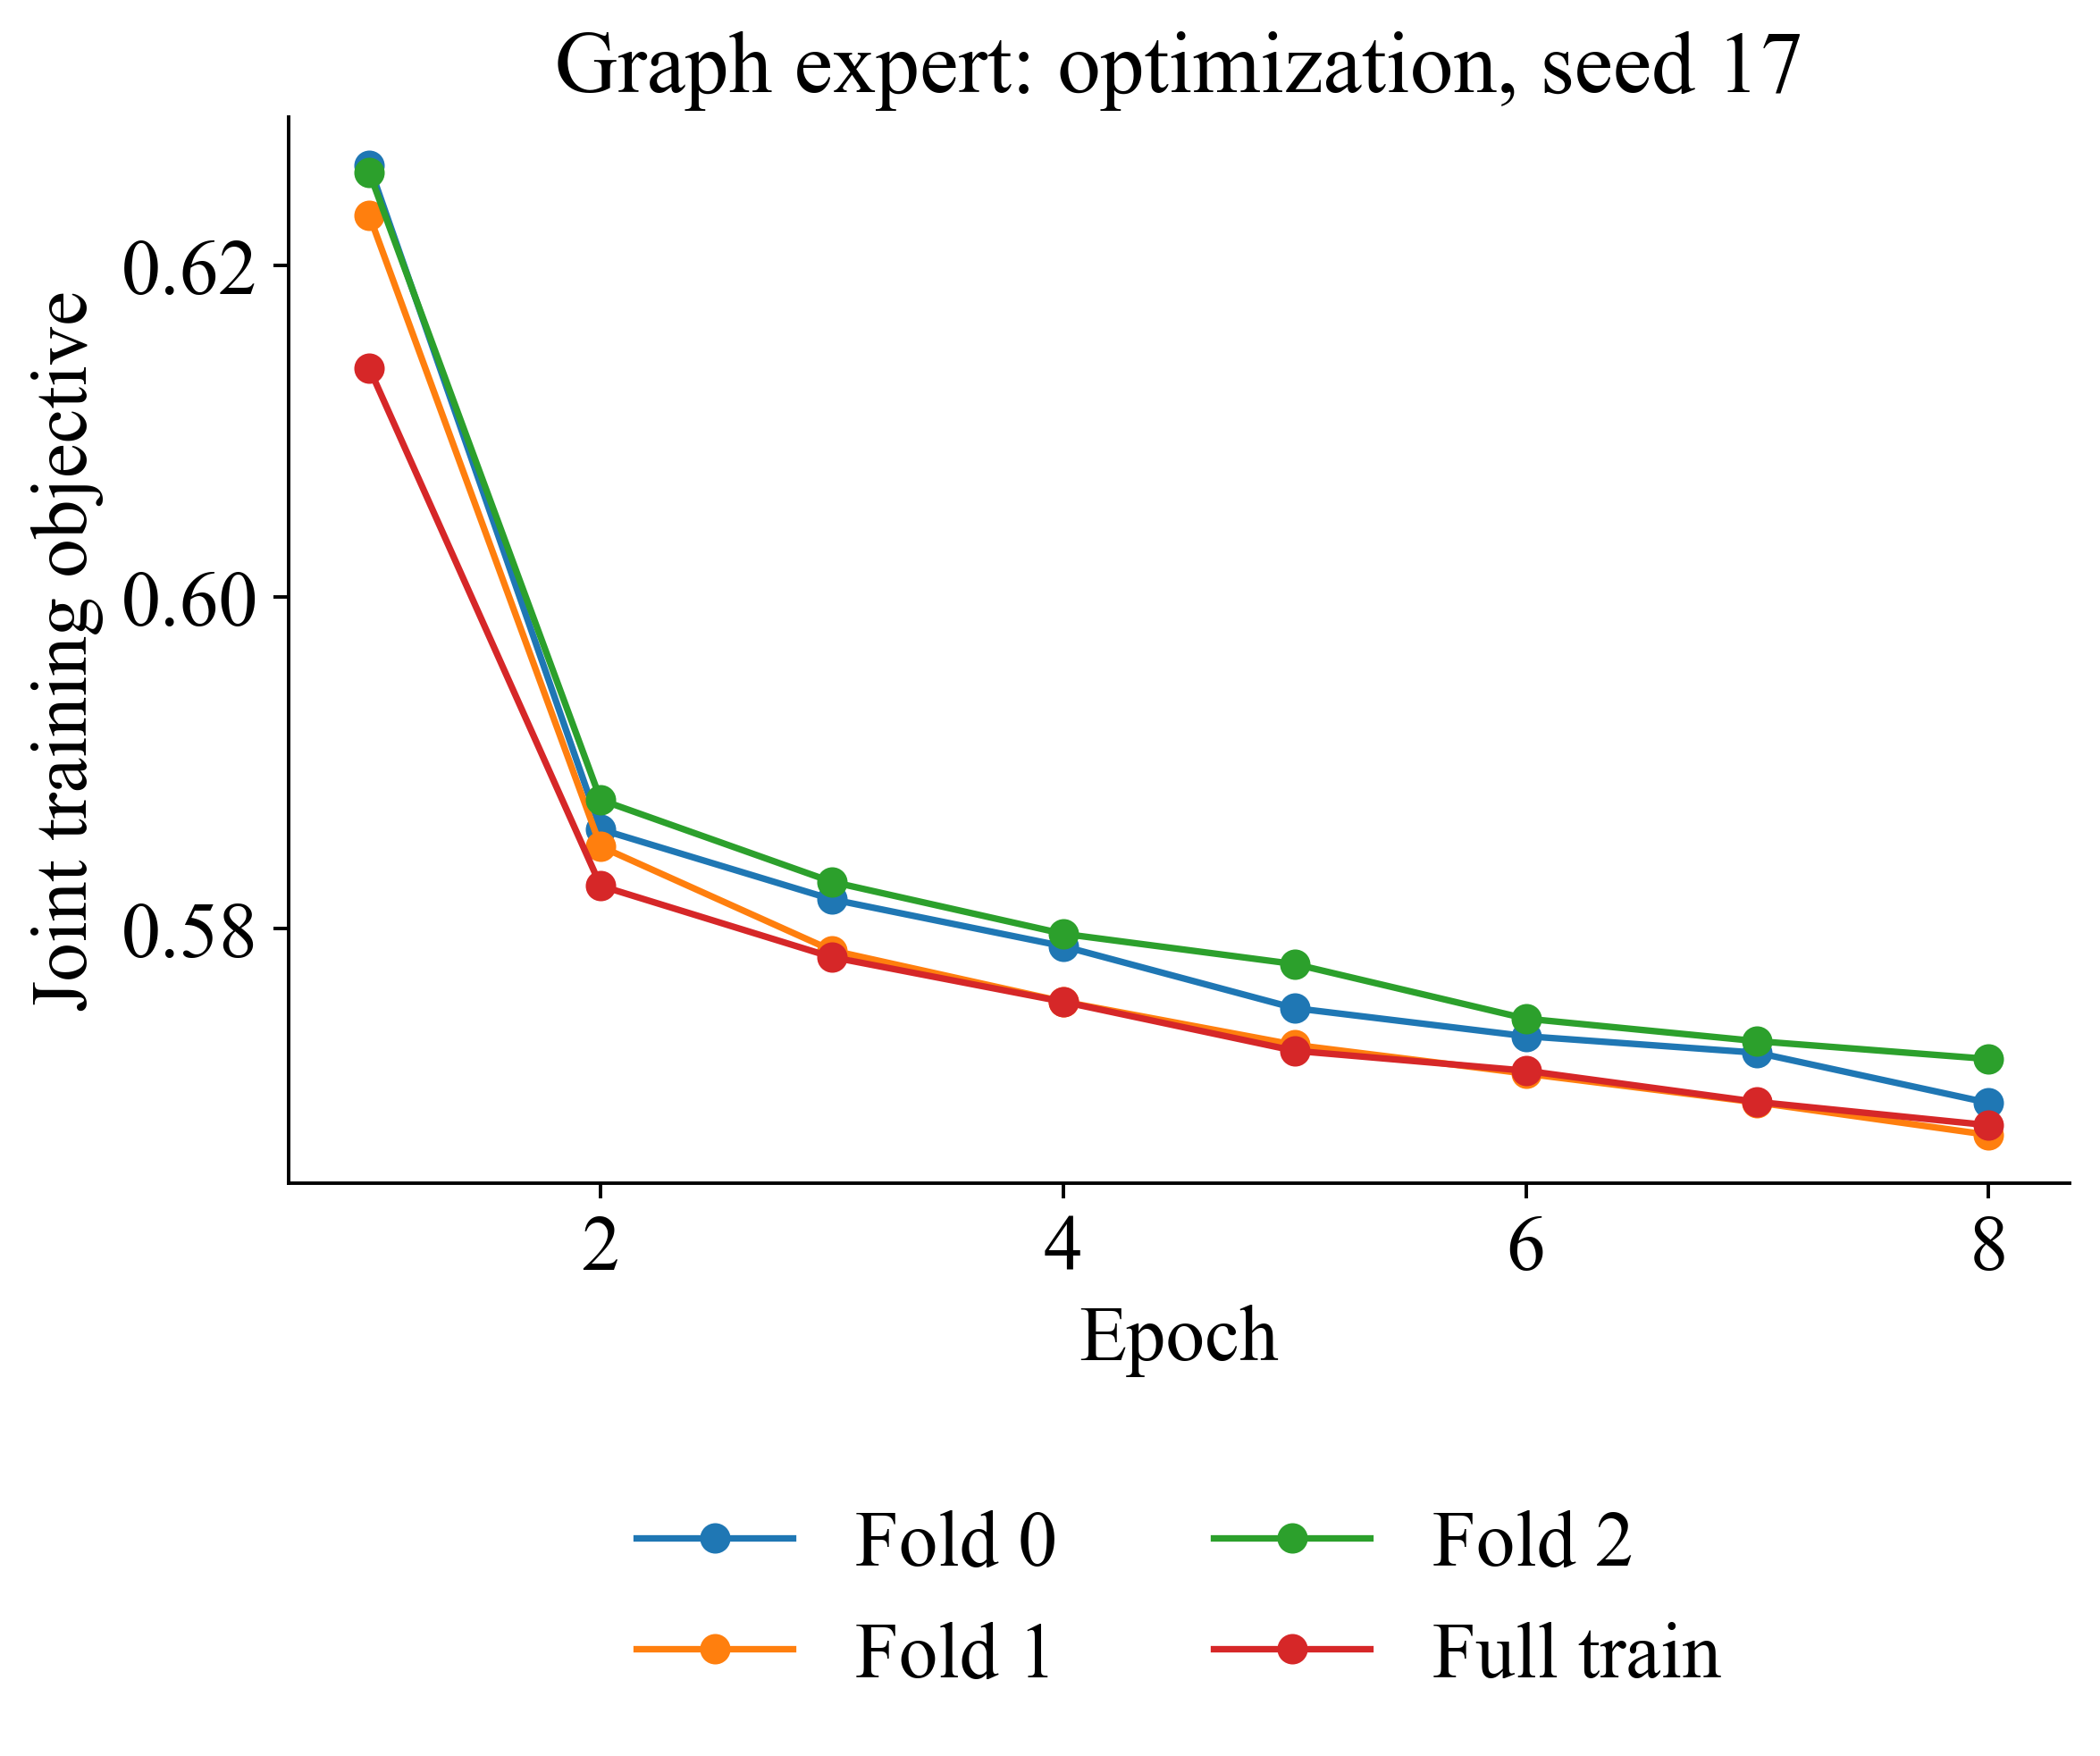

In [11]:
train_component("FullGraph", FULL_CONFIG, SEEDS[0])
curves_frame = pd.DataFrame(graph_curves)
fig, ax = plt.subplots(figsize=(6.6, 5.5), layout="constrained")
for run, group in curves_frame.groupby("Run", sort=False):
    ax.plot(group.Epoch, group["Training objective"], marker="o", label=run)
ax.set(
    xlabel="Epoch",
    ylabel="Joint training objective",
    title="Graph expert: optimization, seed 17",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2, frameon=False
)
save_figure(fig, "05_graph_learning_curves")
plt.show()


## Контроль для цензурированной трудоёмкости

Древесная модель условной интенсивности обучается на событиях успеха и числе наблюдённых неуспешных запусков. Незавершённые попытки не превращаются в известное время успеха. Таблица сравнивает совместную правдоподобность графового эксперта и выбранной основы с этим сильным вспомогательным контролем.

Название базовой модели остаётся таким же, как в блокноте 03/04; во всех сравнениях трудоёмкости её прогноз дополняется общим hazard-контролем.

In [12]:
train_hazard(SEEDS[0])
base_oof, graph_oof, base_valid, graph_valid = paired_components(
    "FullGraph", SEEDS[0]
)
joint_controls = [
    record_joint_metrics(BASE_NAME, SEEDS[0], base_valid),
    record_joint_metrics("GraphTrajectory", SEEDS[0], graph_valid),
]
table(
    pd.DataFrame(joint_controls)[
        ["Model", "Split", "n", "Seed", "Effort_NLL"]
    ],
    "Совместная NLL наблюдаемых запусков ↓",
    "05_joint_controls",
)
save_experiment_state()


Совместная NLL наблюдаемых запусков ↓

,Model,Split,n,Seed,Effort_NLL
0,LightGBM,Validation,23326,17,1.59332
1,GraphTrajectory,Validation,23326,17,1.59246


## Чувствительность адаптивного объединения

На шести недорогих конфигурациях исследуются L2-штраф весов gate и начальное предпочтение основы. Компоненты при этом не переобучаются. Критерий выбора — LogLoss validation. Зависимость от этих настроек должна быть видна независимо от того, улучшается ли качество.

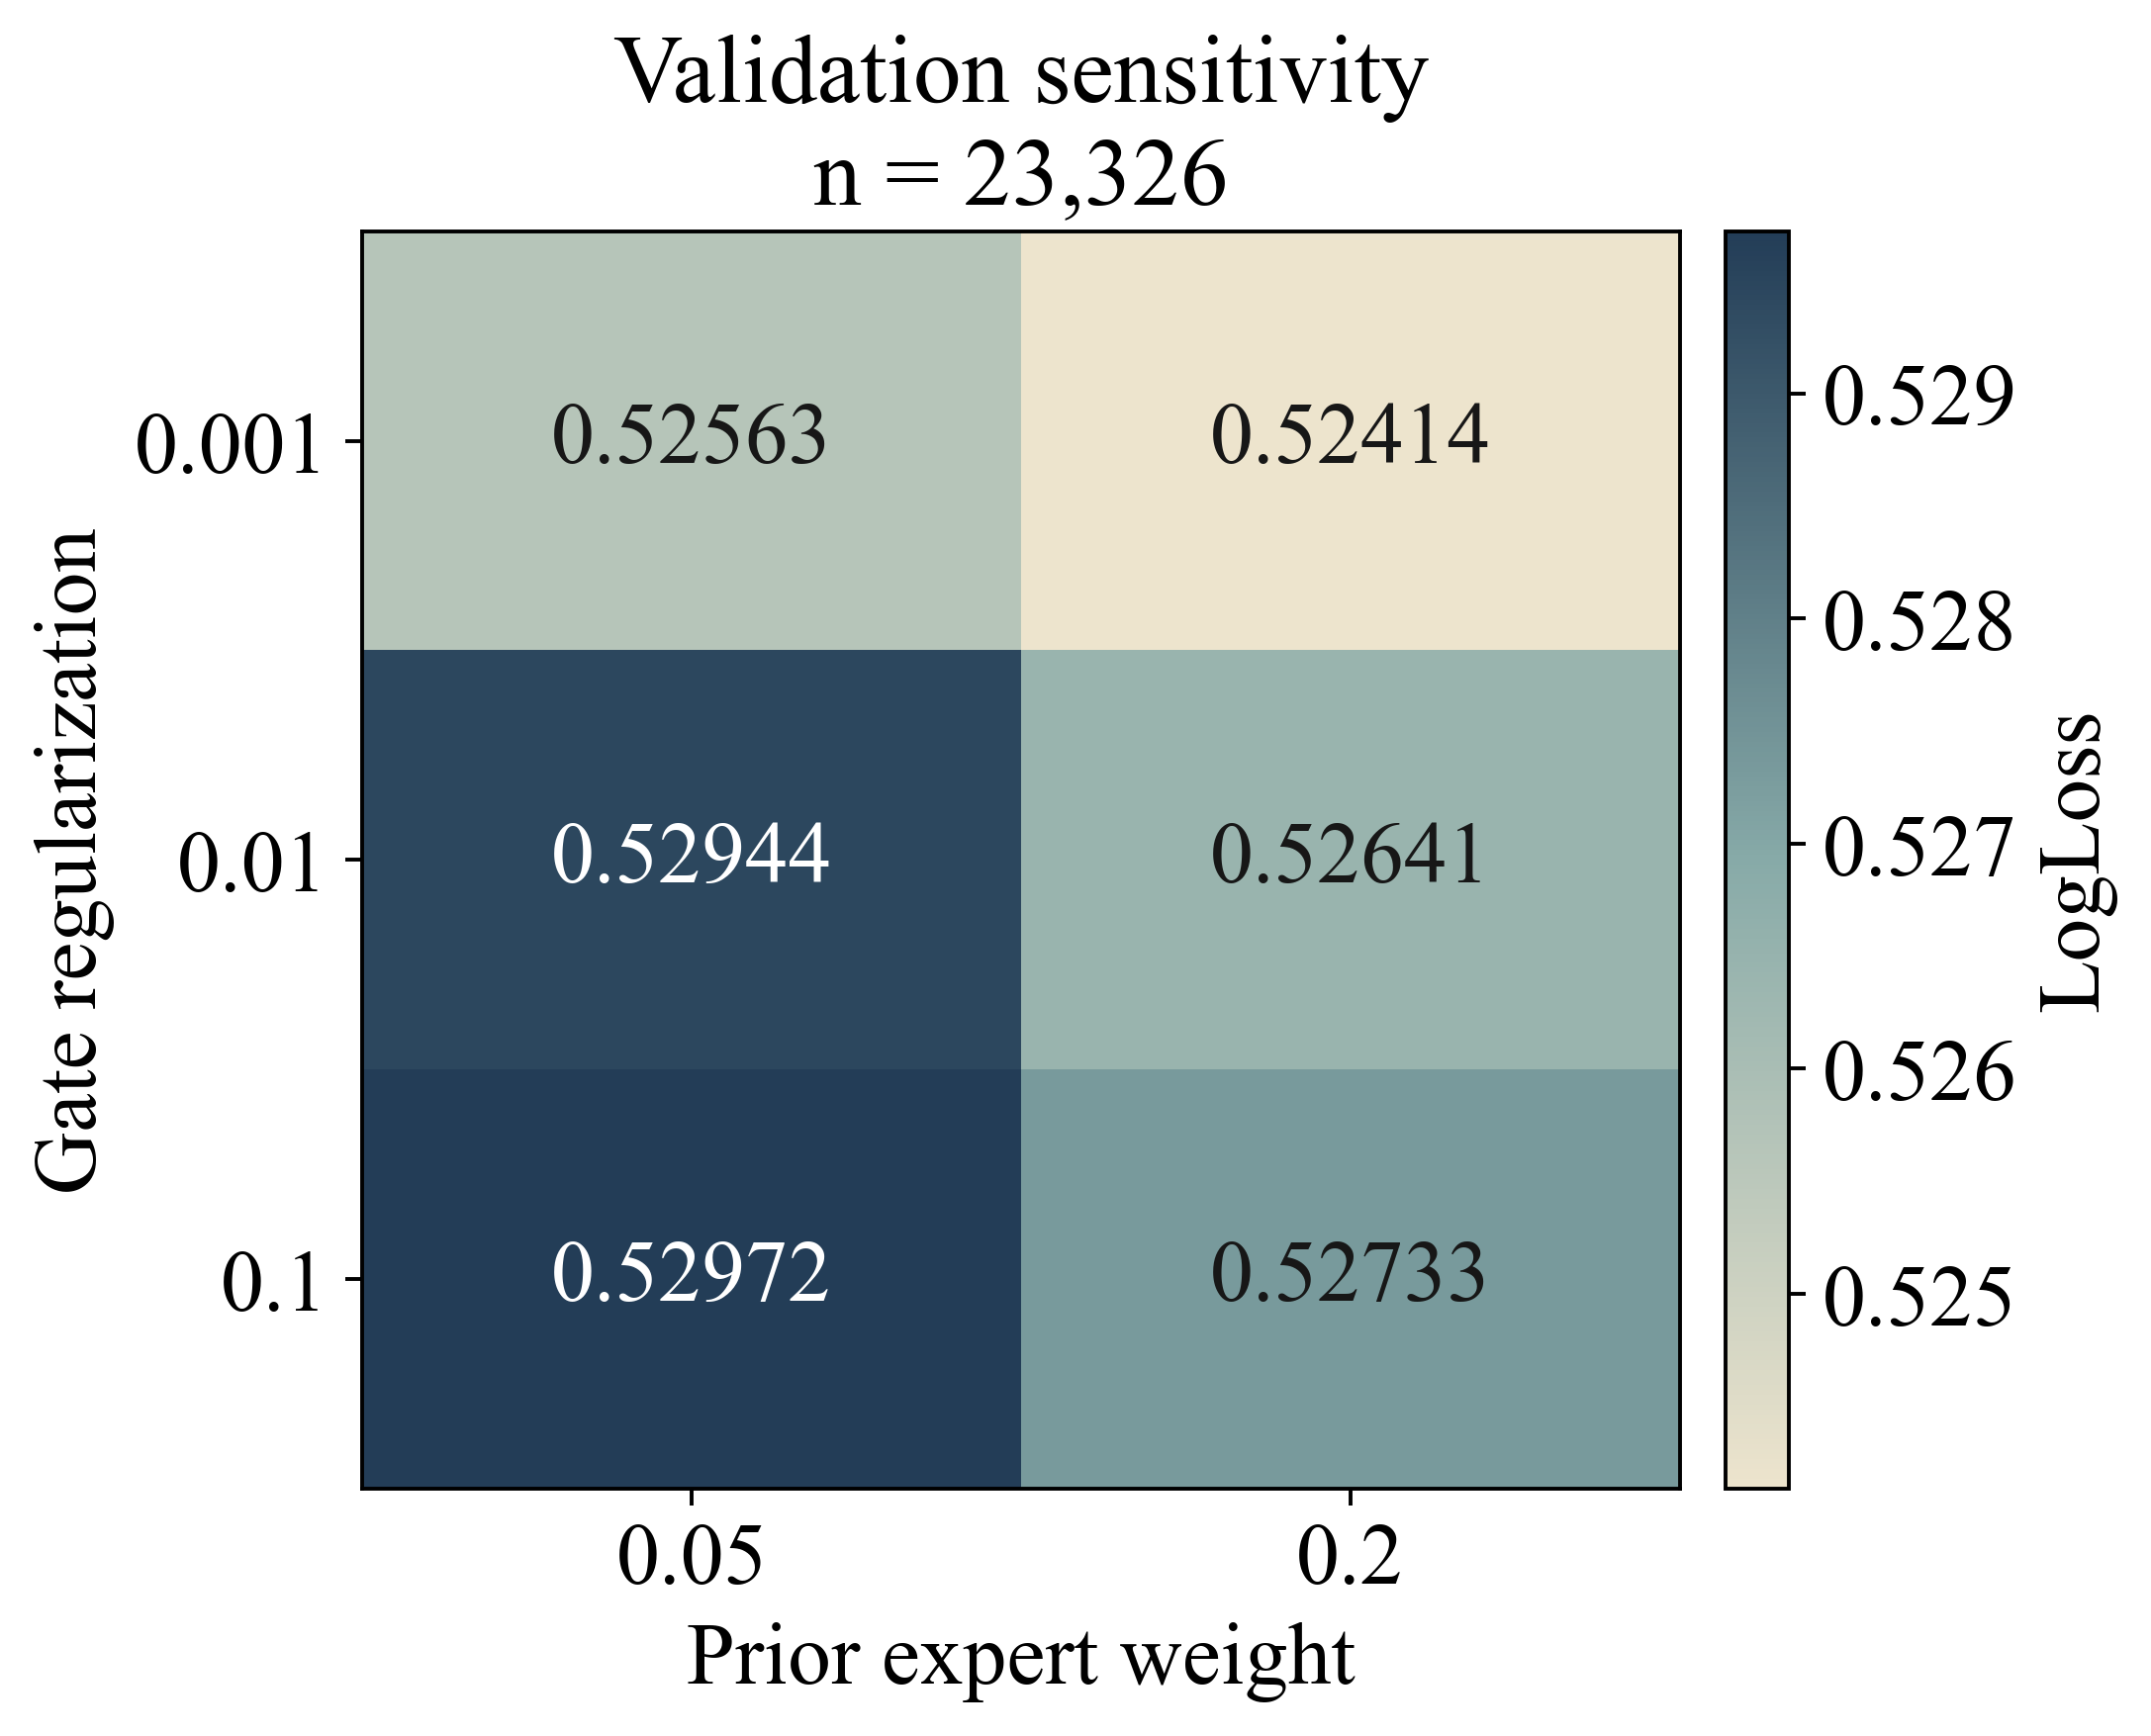

In [13]:
gate_grid, chosen_gate = evaluate_gate_grid(
    base_oof, graph_oof, base_valid, graph_valid, FULL_CONFIG.auxiliary_weight
)
gate_grid.to_csv(ROOT / "artifacts/05_gate_sensitivity.csv", index=False)
gate_results[("AlphaProg-AGMT", SEEDS[0])] = chosen_gate
landscape = gate_grid.pivot(
    index="Regularization", columns="Prior weight", values="LogLoss"
)
fig, ax = plt.subplots(figsize=(6.1, 4.9), layout="constrained")
from matplotlib.colors import LinearSegmentedColormap

artist = ax.imshow(
    landscape.to_numpy(),
    aspect="auto",
    cmap=LinearSegmentedColormap.from_list(
        "alpha_gate", ["#EDE4CD", "#87AAA8", "#233D57"]
    ),
)
ax.set_xticks(
    range(landscape.shape[1]), [f"{value:g}" for value in landscape.columns]
)
ax.set_yticks(
    range(landscape.shape[0]), [f"{value:g}" for value in landscape.index]
)
for i in range(landscape.shape[0]):
    for j in range(landscape.shape[1]):
        rgba = artist.cmap(artist.norm(landscape.iloc[i, j]))
        bright = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
        ax.text(
            j,
            i,
            f"{landscape.iloc[i,j]:.5f}",
            ha="center",
            va="center",
            fontsize=18,
            color="white" if bright < 0.5 else "#171717",
        )
ax.set(
    xlabel="Prior expert weight",
    ylabel="Gate regularization",
    title=f"Validation sensitivity\nn = {len(validation_data):,}",
)
fig.colorbar(artist, ax=ax, label="LogLoss", fraction=0.05, pad=0.035)
save_figure(fig, "05_gate_sensitivity")
plt.show()
save_experiment_state()


## Выбранная конфигурация

Здесь фиксируется только окончательная настройка для последующих seeds. Штраф gate и начальный вес выбраны по предыдущему полотну; остальные значения заданы до обучения. Изменять их по закрытому тесту не разрешается.

In [14]:
configuration_rows = [
    ["Base predictor", BASE_NAME],
    ["Graph width", FULL_CONFIG.width],
    ["Graph steps", FULL_CONFIG.graph_steps],
    ["History limit", GRAPH_HISTORY],
    ["Raw history channels", len(PROCESS_COLUMNS)],
    ["History task descriptors", len(HISTORY_TASK_FEATURES)],
    ["Node limit", FULL_CONFIG.max_nodes],
    ["Epochs", GRAPH_EPOCHS],
    ["Learning rate", GRAPH_LEARNING_RATE],
    ["Auxiliary weight", FULL_CONFIG.auxiliary_weight],
    ["Weight decay", FULL_CONFIG.weight_decay],
    ["Dropout", FULL_CONFIG.dropout],
    ["Gate L2", chosen_gate["regularization"]],
    ["Gate prior", chosen_gate["prior_weight"]],
]
configuration_table = pd.DataFrame(
    configuration_rows, columns=["Parameter", "Value"]
)
configuration_table.insert(0, "Model", "AlphaProg-AGMT")
table(
    configuration_table,
    "Зафиксированная конфигурация",
    "05_selected_configuration",
)


Зафиксированная конфигурация

,Model,Parameter,Value
0,AlphaProg-AGMT,Base predictor,LightGBM
1,AlphaProg-AGMT,Graph width,32
2,AlphaProg-AGMT,Graph steps,2
3,AlphaProg-AGMT,History limit,32
4,AlphaProg-AGMT,Raw history channels,30
5,AlphaProg-AGMT,History task descriptors,8
6,AlphaProg-AGMT,Node limit,64
7,AlphaProg-AGMT,Epochs,8
8,AlphaProg-AGMT,Learning rate,0.001
9,AlphaProg-AGMT,Auxiliary weight,0.1


## Повторяемость полной модели

Основная модель оценивается с seeds 17, 42 и 2026. Для дополнительных seeds сохраняется уже выбранная конфигурация gate. Каждый seed получает собственные OOF-прогнозы компонентов. Разброс по seeds не заменяет доверительный интервал по независимым учащимся.

In [15]:
record_joint_metrics(
    "AlphaProg-AGMT", SEEDS[0], chosen_gate["validation_probability"]
)
for seed in SEEDS[1:]:
    train_component("FullGraph", FULL_CONFIG, seed)
    train_hazard(seed)
    fitted_gate = fit_fixed_gate("FullGraph", seed, chosen_gate)
    gate_results[("AlphaProg-AGMT", seed)] = fitted_gate
    _, _, reference_probability, expert_probability = paired_components(
        "FullGraph", seed
    )
    record_joint_metrics(BASE_NAME, seed, reference_probability)
    record_joint_metrics("GraphTrajectory", seed, expert_probability)
    record_joint_metrics(
        "AlphaProg-AGMT", seed, fitted_gate["validation_probability"]
    )
    save_experiment_state()
joint_metrics = pd.DataFrame(experiment_rows)
probability_summary = (
    joint_metrics.groupby(["Model", "Split", "n"], sort=False)
    .agg(
        LogLoss=("LogLoss", "mean"),
        Seed_SD=("LogLoss", "std"),
        Brier=("Brier", "mean"),
    )
    .reset_index()
)
table(
    probability_summary,
    "Вероятностное качество; LogLoss и Brier ↓",
    "05_probability_quality",
)


Вероятностное качество; LogLoss и Brier ↓

,Model,Split,n,LogLoss,Seed_SD,Brier
0,LightGBM,Validation,23326,0.53074,0.00021,0.17833
1,GraphTrajectory,Validation,23326,0.52478,0.00039,0.17648
2,AlphaProg-AGMT,Validation,23326,0.52377,0.00035,0.17601


## Ранжирование и дополнительная задача

AUROC и AP характеризуют ранжирование первого успеха. Совместная NLL дополнительно учитывает наблюдённую трудоёмкость и цензурирование. Это разные свойства; успех по одному из них не объявляется превосходством по всем показателям.

In [16]:
secondary_summary = (
    joint_metrics.groupby(["Model", "Split", "n"], sort=False)
    .agg(
        AUROC=("AUROC", "mean"),
        AP=("AP", "mean"),
        Effort_NLL=("Effort_NLL", "mean"),
    )
    .reset_index()
)
table(
    secondary_summary, "AUROC и AP ↑; совместная NLL ↓", "05_secondary_quality"
)


AUROC и AP ↑; совместная NLL ↓

,Model,Split,n,AUROC,AP,Effort_NLL
0,LightGBM,Validation,23326,0.80477,0.73935,1.59297
1,GraphTrajectory,Validation,23326,0.80834,0.74117,1.58922
2,AlphaProg-AGMT,Validation,23326,0.80975,0.74411,1.58180


## Абляции механизма

Все абляции используют seed 17 и тот же набор запросов; число эпох и ширина остаются одинаковыми. В NoGraphEncoder удаляется именно графовый модуль, при сохранении общих табличных сводок кода. NoOrder заменяет GRU усреднением. NoAuxLoss исключает вспомогательную потерю; его случайная необученная head не используется, а дополнительный прогноз берётся из того же древесного контроля. NoRegularization исключает dropout, weight decay эксперта и штраф gate; базовая модель остаётся фиксированной. NoEdges сохраняет активные параметры и отключает топологические сообщения.

ConstantFusion — обучаемый постоянный вес, выбранный из того же набора настроек. Лучший одиночный компонент выбирается по validation LogLoss. Архитектурные абляции используют зафиксированные настройки gate полной модели; они оценивают вклад компонентов при данном протоколе и не заменяют полный поиск для каждой архитектуры.

In [17]:
ablation_rows = []
full_row = (
    joint_metrics[
        (joint_metrics.Model.eq("AlphaProg-AGMT"))
        & joint_metrics.Seed.eq(SEEDS[0])
    ]
    .iloc[0]
    .to_dict()
)
ablation_rows.append(full_row)
for variant, configuration in VARIANT_CONFIGS.items():
    train_component(variant, configuration, SEEDS[0])
    fitted_gate = fit_fixed_gate(variant, SEEDS[0], chosen_gate)
    gate_results[(variant, SEEDS[0])] = fitted_gate
    ablation_rows.append(
        record_joint_metrics(
            variant, SEEDS[0], fitted_gate["validation_probability"]
        )
    )
    save_experiment_state()
constant_grid, constant_gate = evaluate_gate_grid(
    base_oof,
    graph_oof,
    base_valid,
    graph_valid,
    FULL_CONFIG.auxiliary_weight,
    adaptive=False,
)
gate_results[("ConstantFusion", SEEDS[0])] = constant_gate
ablation_rows.append(
    record_joint_metrics(
        "ConstantFusion", SEEDS[0], constant_gate["validation_probability"]
    )
)
single_name, single_probability = min(
    [(BASE_NAME, base_valid), ("GraphTrajectory", graph_valid)],
    key=lambda item: log_loss(validation_data.y, item[1][:, 0]),
)
ablation_rows.append(
    record_joint_metrics(
        "BestSingle: " + single_name, SEEDS[0], single_probability
    )
)
ablation_table = pd.DataFrame(ablation_rows)
ablation_table["Delta_LogLoss"] = ablation_table.LogLoss - full_row["LogLoss"]
ablation_table.to_csv(
    ROOT / "artifacts/05_all_ablation_metrics.csv", index=False
)
table(
    ablation_table[["Model", "Split", "n", "LogLoss", "Delta_LogLoss"]],
    "Абляции: LogLoss ↓; положительная Δ означает ухудшение относительно полной модели",
    "05_ablation_primary",
)
save_experiment_state()


Абляции: LogLoss ↓; положительная Δ означает ухудшение относительно полной модели

,Model,Split,n,LogLoss,Delta_LogLoss
0,AlphaProg-AGMT,Validation,23326,0.52414,0.00000
1,NoGraphEncoder,Validation,23326,0.52522,0.00108
2,NoOrder,Validation,23326,0.52727,0.00313
3,NoAuxLoss,Validation,23326,0.52405,-0.00008
4,NoRegularization,Validation,23326,0.52318,-0.00096
5,NoEdges,Validation,23326,0.52529,0.00115
6,ConstantFusion,Validation,23326,0.52515,0.00102
7,BestSingle: GraphTrajectory,Validation,23326,0.52515,0.00101


## Дополнительные последствия абляций

Изменения Brier и совместной NLL позволяют установить, связан ли выигрыш первого прогноза с улучшением вероятностей и трудоёмкости. Влияние вспомогательной задачи не предполагается положительным заранее.

In [18]:
table(
    ablation_table[["Model", "Split", "n", "Brier", "Effort_NLL"]],
    "Абляции: Brier и совместная NLL ↓",
    "05_ablation_secondary",
)


Абляции: Brier и совместная NLL ↓

,Model,Split,n,Brier,Effort_NLL
0,AlphaProg-AGMT,Validation,23326,0.17612,1.58317
1,NoGraphEncoder,Validation,23326,0.17644,1.58385
2,NoOrder,Validation,23326,0.17716,1.58661
3,NoAuxLoss,Validation,23326,0.17607,1.58673
4,NoRegularization,Validation,23326,0.17592,1.58300
5,NoEdges,Validation,23326,0.17650,1.58455
6,ConstantFusion,Validation,23326,0.17644,1.58444
7,BestSingle: GraphTrajectory,Validation,23326,0.17666,1.59246


## Поведение адаптивных весов

Зависит ли доверие к структурно-временному эксперту от доступности истории и раздела задания? Рисунок показывает медиану веса и межквартильный диапазон по запросам validation для seed 17. Это описание работы gate, а не причинная важность переменных.

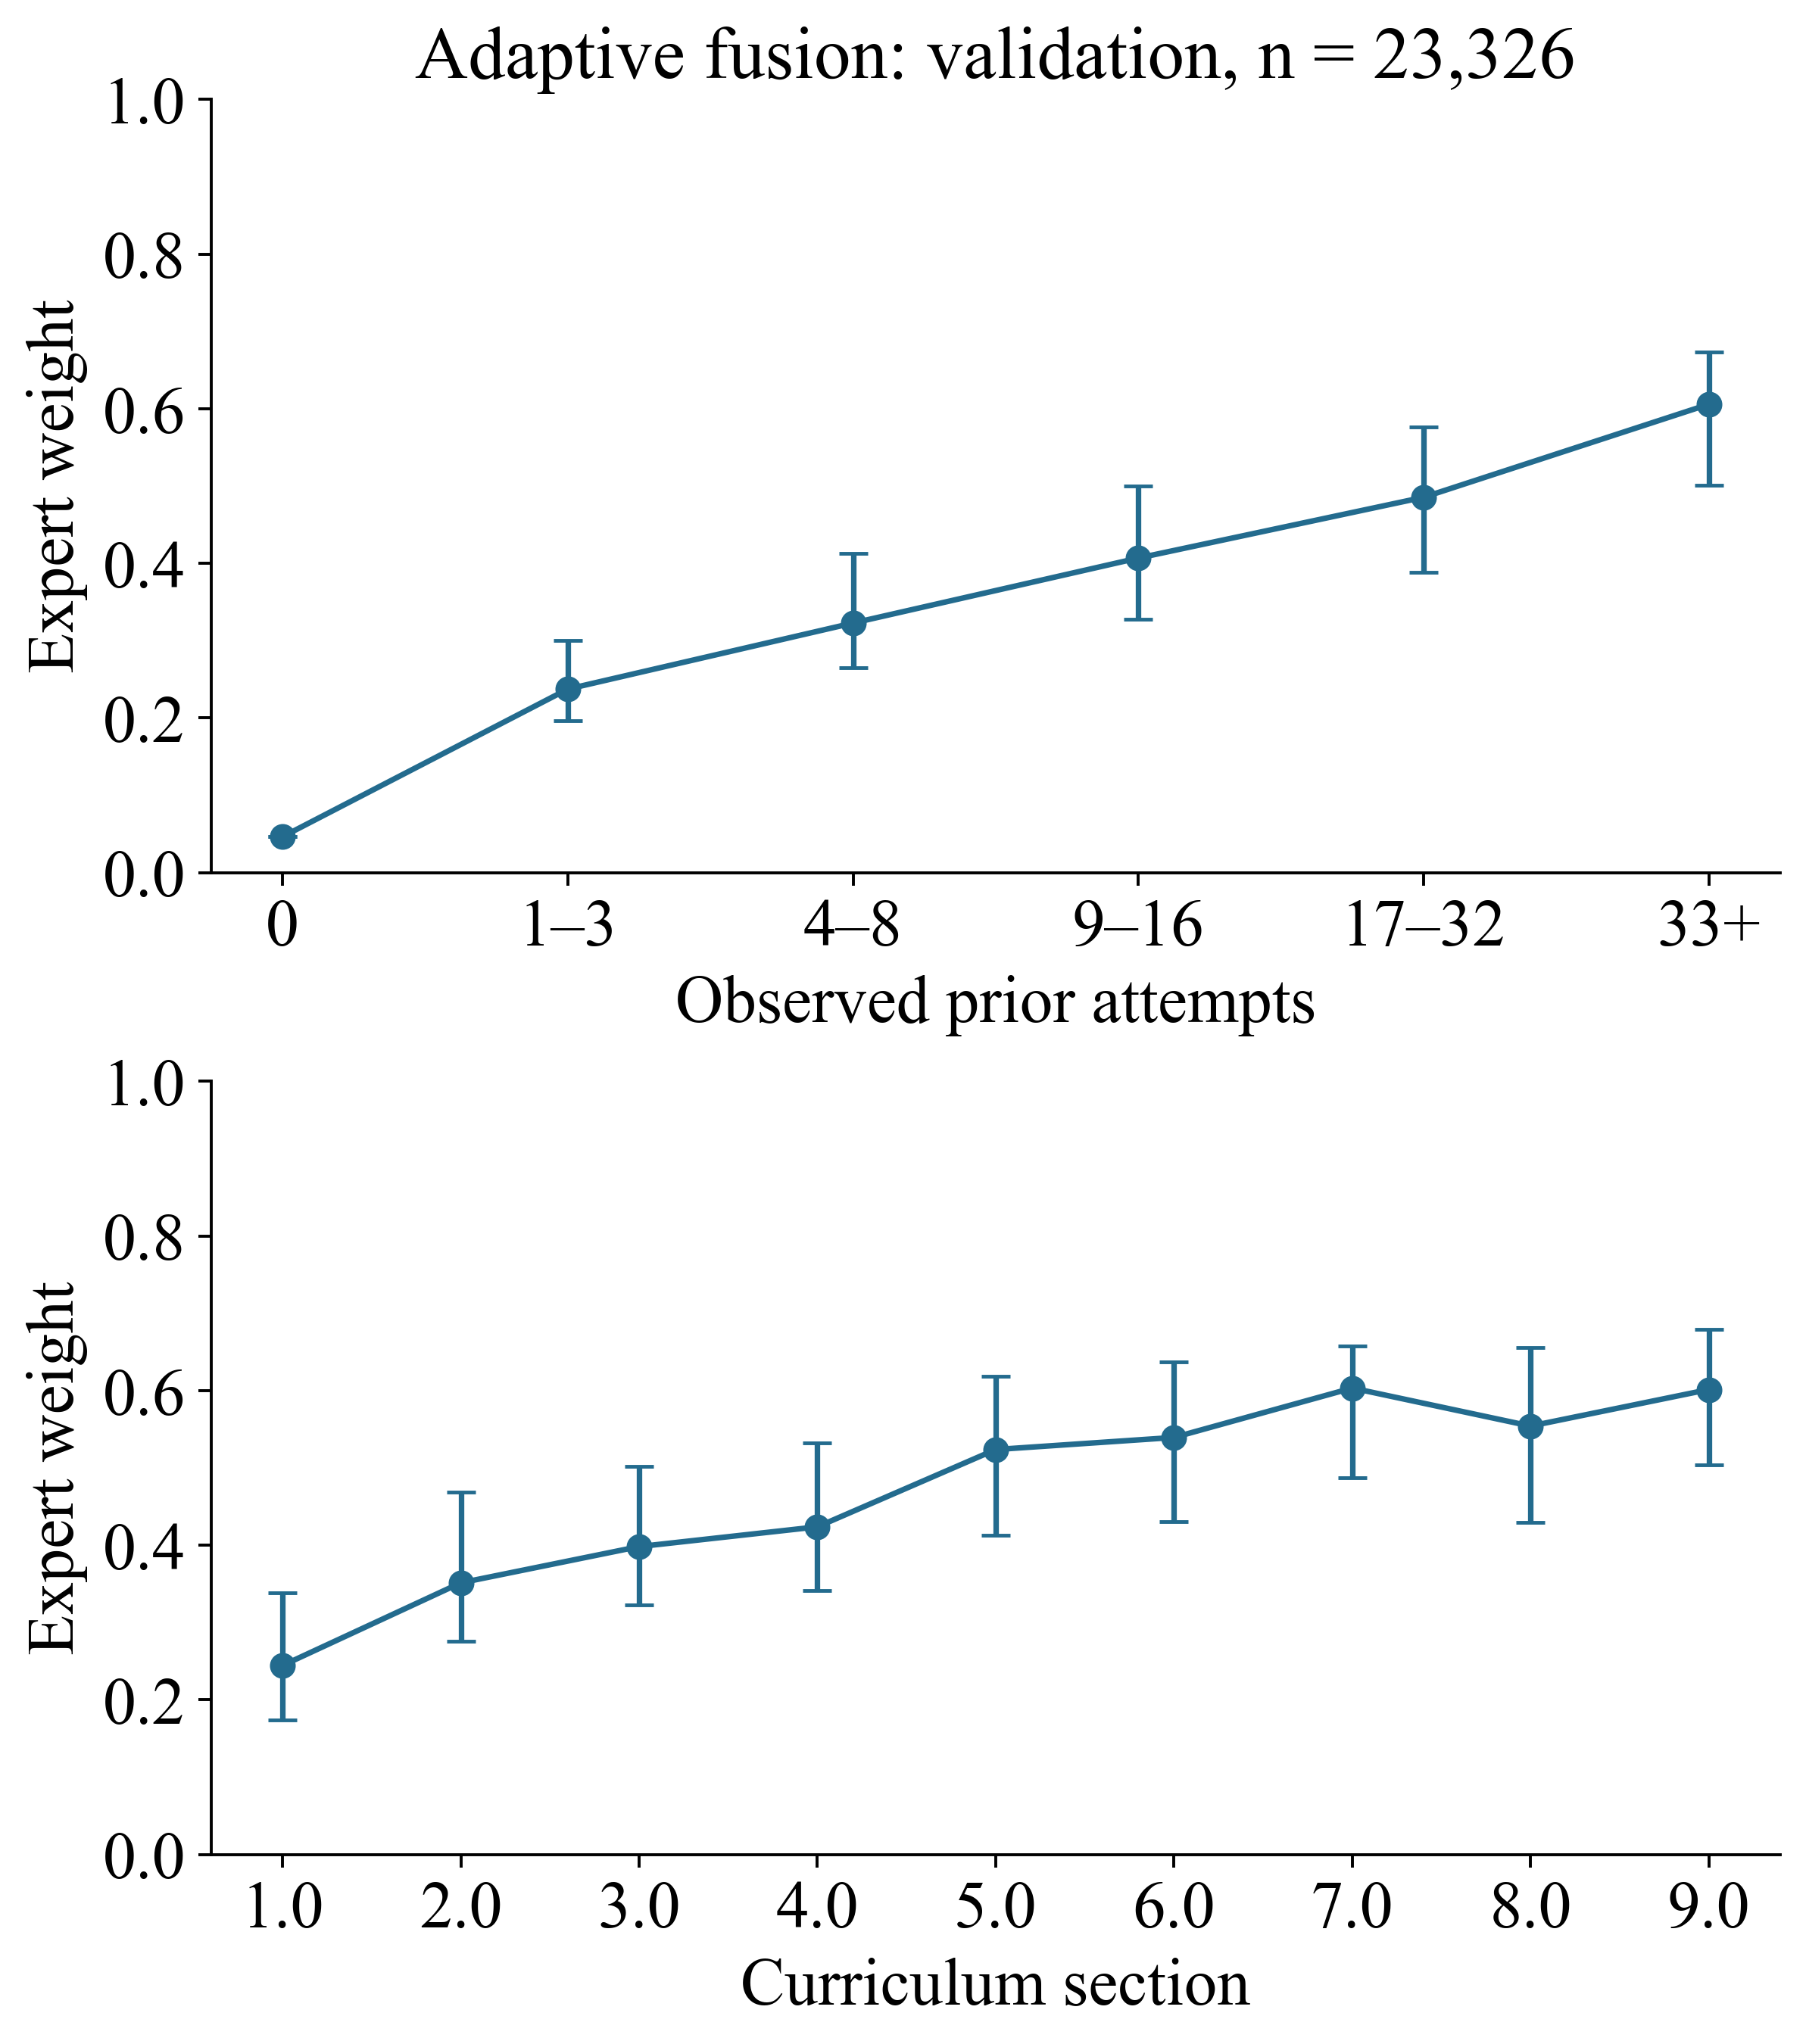

In [19]:
weight_frame = validation_data[["history_n", "q_level"]].copy()
weight_frame["Expert weight"] = chosen_gate["validation_weight"]
weight_frame["History group"] = pd.cut(
    weight_frame.history_n,
    bins=[-1, 0, 3, 8, 16, 32, np.inf],
    labels=["0", "1–3", "4–8", "9–16", "17–32", "33+"],
)
weight_frame.to_csv(ROOT / "artifacts/05_gate_behavior.csv", index=False)
fig, axes = plt.subplots(2, 1, figsize=(6.7, 7.6), layout="constrained")
for ax, grouping, label in zip(
    axes,
    ["History group", "q_level"],
    ["Observed prior attempts", "Curriculum section"],
):
    grouped = weight_frame.groupby(grouping, observed=True)["Expert weight"]
    median = grouped.median()
    low = grouped.quantile(0.25)
    high = grouped.quantile(0.75)
    positions = np.arange(len(median))
    ax.errorbar(
        positions,
        median,
        yerr=np.vstack([median - low, high - median]),
        fmt="o-",
        color="#236B8E",
        capsize=4,
    )
    ax.set_xticks(positions, median.index.astype(str))
    ax.set(xlabel=label, ylabel="Expert weight", ylim=(0, 1))
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_title(f"Adaptive fusion: validation, n = {len(weight_frame):,}")
save_figure(fig, "05_gate_behavior")
plt.show()


## Вычислительные затраты эксперта

Показано фактическое время полного обучения и предсказания, число активных параметров и размер сохранённого состояния. Для полного пути inference к этим затратам необходимо добавить выбранную основу, hazard и gate. Размер Model_MB относится к checkpoint с весами и обучающим словарём; входной синтаксический кэш и отдельный объект preprocessing в него не включены. В итоговом сравнении блокнота 6 отдельно учитывается полный сохранённый комплект весов, словаря и обученных преобразований. Размер файла не является измерением пиковой оперативной памяти.

In [20]:
efficiency_table = (
    pd.DataFrame(graph_efficiency)
    .groupby(["Model", "Split", "n"], sort=False)
    .agg(
        Train_s=("Train_s", "median"),
        Inference_s=("Inference_s", "median"),
        Parameters=("Parameters", "median"),
        Model_MB=("Model_MB", "median"),
    )
    .reset_index()
)
table(
    efficiency_table,
    "Затраты структурно-временных вариантов; медианы измерений",
    "05_efficiency",
)
assert (
    efficiency_table.set_index("Model").loc["FullGraph", "Parameters"]
    == efficiency_table.set_index("Model").loc["NoEdges", "Parameters"]
)


Затраты структурно-временных вариантов; медианы измерений

,Model,Split,n,Train_s,Inference_s,Parameters,Model_MB
0,FullGraph,Validation,23326,198.68786,1.30295,25506.0,0.11289
1,NoGraphEncoder,Validation,23326,143.11516,0.83534,14594.0,0.06394
2,NoOrder,Validation,23326,112.53182,0.89646,19170.0,0.08632
3,NoAuxLoss,Validation,23326,195.54074,1.38179,25473.0,0.11289
4,NoRegularization,Validation,23326,238.92205,1.81951,25506.0,0.11312
5,NoEdges,Validation,23326,208.49715,1.35814,25506.0,0.11282


## Граница последующего анализа

Архитектура, настройки и абляции после этого этапа фиксируются до открытия теста. Полученные validation-результаты использовались при выборе и потому не являются окончательным подтверждением превосходства. Следующий блокнот оценивает закрытый тест, статистическую неопределённость, подгруппы, калибровку, характер ошибок и ограниченные сценарии устойчивости.

In [21]:
save_experiment_state()
frozen = {
    "feature_revision": contract["feature_revision"],
    "base": BASE_NAME,
    "model": "AlphaProg-AGMT",
    "seeds": SEEDS,
    "graph_config": vars(FULL_CONFIG),
    "epochs": GRAPH_EPOCHS,
    "batch_size": GRAPH_BATCH_SIZE,
    "learning_rate": GRAPH_LEARNING_RATE,
    "gate_regularization": chosen_gate["regularization"],
    "gate_prior": chosen_gate["prior_weight"],
    "selection_split": "Validation",
    "locked_test_opened": False,
    "practical_logloss_difference": 0.005,
    "history_limit": GRAPH_HISTORY,
    "history_task_features": HISTORY_TASK_FEATURES,
    "history_process_features": PROCESS_COLUMNS,
    "probability_aggregation": "arithmetic_mean_across_seeds",
    "effort_seed_aggregation": "mean_p_and_q_then_geometric_cdf",
    "robust_history_mask_fractions": [0.0, 0.1, 0.3],
    "effort_horizons": [1, 3, 5, 10],
    "secondary_effort_comparators": [
        base_decision["best_ml"],
        base_decision["best_dl"],
    ],
    "secondary_effort_intervals": "learner_bootstrap_95pct_pointwise",
    "primary_bootstrap_repetitions": 1000,
    "paired_randomization_repetitions": 2000,
    "familywise_correction": "Holm",
    "ablation_variants": list(VARIANT_CONFIGS),
    "ablation_best_single": "base" if single_name == BASE_NAME else "graph",
    "primary_models": [
        "GlobalMean",
        "ItemMean",
        "LogisticRegression",
        "RandomForest",
        "XGBoost",
        "LightGBM",
        "DKT",
        "AKT",
        "UKT",
        "TabM",
        "GraphTrajectory",
        "AlphaProg-AGMT",
    ],
}
frozen_path = ROOT / "dataset/protocol/frozen_proposed_model.json"
if (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists():
    assert (
        json.loads(frozen_path.read_text()) == frozen
    ), "Reproduction changed the frozen configuration."
else:
    frozen_path.write_text(json.dumps(frozen, indent=2))
source_fingerprints = {}
for training_path in sorted((ROOT / "notebooks").glob("0[1-5]*.ipynb")):
    training_notebook = json.loads(training_path.read_text())
    training_source = "\n\n".join(
        "".join(cell["source"])
        for cell in training_notebook["cells"]
        if cell["cell_type"] == "code"
    )
    source_fingerprints[training_path.name] = hashlib.sha256(
        training_source.encode()
    ).hexdigest()
fingerprint_path = ROOT / "dataset/protocol/frozen_training_sources.json"
fingerprint_record = {
    "feature_revision": contract["feature_revision"],
    "notebooks": source_fingerprints,
}
if (ROOT / "dataset/protocol/test_evaluation_boundary.json").exists():
    assert json.loads(fingerprint_path.read_text()) == fingerprint_record
else:
    fingerprint_path.write_text(json.dumps(fingerprint_record, indent=2));
